In [1]:
!git clone https://github.com/yuqinie98/PatchTST.git
!pip install einops

Cloning into 'PatchTST'...
remote: Enumerating objects: 352, done.
remote: Total 352 (delta 0), reused 0 (delta 0), pack-reused 352 (from 1)
Receiving objects: 100% (352/352), 12.92 MiB | 29.34 MiB/s, done.
Resolving deltas: 100% (155/155), done.


In [2]:
import os
import shutil
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/chongwentang/clean-data/clean_data.csv")
print("原始列名:", df.columns.tolist())
print(f"数据总行数: {len(df)}")
print(df.head())

df = df.rename(columns={"Time": "date"})
print("处理后列名:", df.columns.tolist())

target_dir = "/kaggle/working/PatchTST/PatchTST_supervised/dataset/custom"
os.makedirs(target_dir, exist_ok=True)
df.to_csv(f"{target_dir}/data.csv", index=False)
print("✅ 数据保存完成, shape:", df.shape)

原始列名: ['Time', 'LMP']
数据总行数: 96562
                        Time       LMP
0  2024-01-01 08:00:00+00:00  45.18881
1  2024-01-01 08:05:00+00:00  45.69934
2  2024-01-01 08:10:00+00:00  45.69934
3  2024-01-01 08:15:00+00:00  45.61815
4  2024-01-01 08:20:00+00:00  45.61815
处理后列名: ['date', 'LMP']
✅ 数据保存完成, shape: (96562, 2)


In [3]:
import os

project_dir = '/kaggle/working/PatchTST/PatchTST_supervised'
fixed_files = []
for root, dirs, files in os.walk(project_dir):
    for fname in files:
        if fname.endswith('.py'):
            fpath = os.path.join(root, fname)
            with open(fpath, 'r', errors='ignore') as f:
                content = f.read()
            if 'np.Inf' in content:
                content = content.replace('np.Inf', 'np.inf')
                with open(fpath, 'w') as f:
                    f.write(content)
                fixed_files.append(fpath)
print(f"✅ 共修复 {len(fixed_files)} 个文件")

✅ 共修复 2 个文件


In [4]:
# PatchTST默认划分是7:1:2，需要确认data_provider里的比例
# 找到dataset文件修改划分比例
import os

# 找data_loader.py
for root, dirs, files in os.walk('/kaggle/working/PatchTST/PatchTST_supervised'):
    for f in files:
        if 'data_loader' in f or 'dataset' in f.lower():
            print(os.path.join(root, f))

/kaggle/working/PatchTST/PatchTST_supervised/Formers/FEDformer/data_provider/data_loader.py
/kaggle/working/PatchTST/PatchTST_supervised/Formers/Pyraformer/data_loader.py
/kaggle/working/PatchTST/PatchTST_supervised/data_provider/data_loader.py


In [5]:
# 读取data_loader.py，确认划分逻辑
loader_path = '/kaggle/working/PatchTST/PatchTST_supervised/data_provider/data_loader.py'
with open(loader_path, 'r') as f:
    content = f.read()

# 打印关键划分部分
for i, line in enumerate(content.split('\n')):
    if any(k in line for k in ['border', '0.7', '0.8', 'num_train', 'num_test', 'num_vali']):
        print(f"Line {i}: {line}")

Line 47:         border1s = [0, 12 * 30 * 24 - self.seq_len, 12 * 30 * 24 + 4 * 30 * 24 - self.seq_len]
Line 48:         border2s = [12 * 30 * 24, 12 * 30 * 24 + 4 * 30 * 24, 12 * 30 * 24 + 8 * 30 * 24]
Line 49:         border1 = border1s[self.set_type]
Line 50:         border2 = border2s[self.set_type]
Line 59:             train_data = df_data[border1s[0]:border2s[0]]
Line 65:         df_stamp = df_raw[['date']][border1:border2]
Line 77:         self.data_x = data[border1:border2]
Line 78:         self.data_y = data[border1:border2]
Line 135:         border1s = [0, 12 * 30 * 24 * 4 - self.seq_len, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4 - self.seq_len]
Line 136:         border2s = [12 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 8 * 30 * 24 * 4]
Line 137:         border1 = border1s[self.set_type]
Line 138:         border2 = border2s[self.set_type]
Line 147:             train_data = df_data[border1s[0]:border2s[0]]
Line 153:         df_stamp = df_raw[['date']][borde

In [6]:
# 强制修改为7:1:2划分
loader_path = '/kaggle/working/PatchTST/PatchTST_supervised/data_provider/data_loader.py'
with open(loader_path, 'r') as f:
    content = f.read()

# 替换划分比例（PatchTST原始用的是border1/border2）
old_split = """        num_train = int(len(df) * 0.7)
        num_test = int(len(df) * 0.2)
        num_vali = len(df) - num_train - num_test"""

new_split = """        num_train = int(len(df) * 0.7)
        num_test = int(len(df) * 0.2)
        num_vali = len(df) - num_train - num_test"""

# 先打印当前划分方式确认
print("当前划分逻辑:")
lines = content.split('\n')
for i, line in enumerate(lines):
    if 'num_train' in line or 'num_test' in line or 'num_vali' in line or 'border' in line:
        print(f"  Line {i+1}: {line}")

当前划分逻辑:
  Line 48:         border1s = [0, 12 * 30 * 24 - self.seq_len, 12 * 30 * 24 + 4 * 30 * 24 - self.seq_len]
  Line 49:         border2s = [12 * 30 * 24, 12 * 30 * 24 + 4 * 30 * 24, 12 * 30 * 24 + 8 * 30 * 24]
  Line 50:         border1 = border1s[self.set_type]
  Line 51:         border2 = border2s[self.set_type]
  Line 60:             train_data = df_data[border1s[0]:border2s[0]]
  Line 66:         df_stamp = df_raw[['date']][border1:border2]
  Line 78:         self.data_x = data[border1:border2]
  Line 79:         self.data_y = data[border1:border2]
  Line 136:         border1s = [0, 12 * 30 * 24 * 4 - self.seq_len, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4 - self.seq_len]
  Line 137:         border2s = [12 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 4 * 30 * 24 * 4, 12 * 30 * 24 * 4 + 8 * 30 * 24 * 4]
  Line 138:         border1 = border1s[self.set_type]
  Line 139:         border2 = border2s[self.set_type]
  Line 148:             train_data = df_data[border1s[0]:border2s[0]]
  Line 154:      

In [7]:
%cd /kaggle/working/PatchTST/PatchTST_supervised

!python run_longExp.py \
  --is_training 1 \
  --root_path ./dataset/custom/ \
  --data_path data.csv \
  --model_id electricity \
  --model PatchTST \
  --data custom \
  --features S \
  --target LMP \
  --seq_len 288 \
  --label_len 144 \
  --pred_len 288 \
  --enc_in 1 \
  --d_model 128 \
  --n_heads 16 \
  --e_layers 3 \
  --d_ff 256 \
  --dropout 0.2 \
  --fc_dropout 0.2 \
  --head_dropout 0 \
  --patch_len 16 \
  --stride 8 \
  --des test \
  --batch_size 32 \
  --train_epochs 10 \
  --patience 3 \
  --learning_rate 0.0001 \
  --lradj type3 \
  --itr 1

/kaggle/working/PatchTST/PatchTST_supervised
Args in experiment:
Namespace(random_seed=2021, is_training=1, model_id='electricity', model='PatchTST', data='custom', root_path='./dataset/custom/', data_path='data.csv', features='S', target='LMP', freq='h', checkpoints='./checkpoints/', seq_len=288, label_len=144, pred_len=288, fc_dropout=0.2, head_dropout=0.0, patch_len=16, stride=8, padding_patch='end', revin=1, affine=0, subtract_last=0, decomposition=0, kernel_size=25, individual=0, embed_type=0, enc_in=1, dec_in=7, c_out=7, d_model=128, n_heads=16, e_layers=3, d_layers=1, d_ff=256, moving_avg=25, factor=1, distil=True, dropout=0.2, embed='timeF', activation='gelu', output_attention=False, do_predict=False, num_workers=10, itr=1, train_epochs=10, batch_size=32, patience=3, learning_rate=0.0001, des='test', loss='mse', lradj='type3', pct_start=0.3, use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', test_flop=False)
Use GPU: cuda:0
>>>>>>>start training : elect

In [8]:
%cd /kaggle/working/PatchTST/PatchTST_supervised

!python run_longExp.py \
  --is_training 0 \
  --root_path ./dataset/custom/ \
  --data_path data.csv \
  --model_id electricity \
  --model PatchTST \
  --data custom \
  --features S \
  --target LMP \
  --seq_len 288 \
  --label_len 144 \
  --pred_len 288 \
  --enc_in 1 \
  --d_model 128 \
  --n_heads 16 \
  --e_layers 3 \
  --d_ff 256 \
  --dropout 0.2 \
  --fc_dropout 0.2 \
  --head_dropout 0 \
  --patch_len 16 \
  --stride 8 \
  --des test \
  --batch_size 32 \
  --train_epochs 10 \
  --patience 3 \
  --learning_rate 0.0001 \
  --lradj type3 \
  --itr 1

/kaggle/working/PatchTST/PatchTST_supervised
Args in experiment:
Namespace(random_seed=2021, is_training=0, model_id='electricity', model='PatchTST', data='custom', root_path='./dataset/custom/', data_path='data.csv', features='S', target='LMP', freq='h', checkpoints='./checkpoints/', seq_len=288, label_len=144, pred_len=288, fc_dropout=0.2, head_dropout=0.0, patch_len=16, stride=8, padding_patch='end', revin=1, affine=0, subtract_last=0, decomposition=0, kernel_size=25, individual=0, embed_type=0, enc_in=1, dec_in=7, c_out=7, d_model=128, n_heads=16, e_layers=3, d_layers=1, d_ff=256, moving_avg=25, factor=1, distil=True, dropout=0.2, embed='timeF', activation='gelu', output_attention=False, do_predict=False, num_workers=10, itr=1, train_epochs=10, batch_size=32, patience=3, learning_rate=0.0001, des='test', loss='mse', lradj='type3', pct_start=0.3, use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', test_flop=False)
Use GPU: cuda:0
>>>>>>>testing : electricity_

In [9]:
exp_path = '/kaggle/working/PatchTST/PatchTST_supervised/exp/exp_main.py'
with open(exp_path, 'r', errors='ignore') as f:
    content = f.read()

# 取消注释true.npy和metrics.npy
content = content.replace(
    "# np.save(folder_path + 'metrics.npy', np.array([mae, mse, rmse, mape, mspe,rse, corr]))",
    "np.save(folder_path + 'metrics.npy', np.array([mae, mse, rmse, mape, mspe,rse, corr]))"
)
content = content.replace(
    "# np.save(folder_path + 'true.npy', trues)",
    "np.save(folder_path + 'true.npy', trues)"
)
content = content.replace(
    "# np.save(folder_path + 'x.npy', inputx)",
    "np.save(folder_path + 'x.npy', inputx)"
)

with open(exp_path, 'w') as f:
    f.write(content)
print("✅ 修复完成，true.npy将被保存")

# 验证
with open(exp_path, 'r') as f:
    for i, line in enumerate(f, 1):
        if 'true.npy' in line or 'metrics.npy' in line:
            print(f"Line {i}: {line.rstrip()}")

✅ 修复完成，true.npy将被保存
Line 309:         np.save(folder_path + 'metrics.npy', np.array([mae, mse, rmse, mape, mspe,rse, corr]))
Line 311:         np.save(folder_path + 'true.npy', trues)


In [10]:
# 修复metrics报错
exp_path = '/kaggle/working/PatchTST/PatchTST_supervised/exp/exp_main.py'
with open(exp_path, 'r', errors='ignore') as f:
    content = f.read()

content = content.replace(
    "np.save(folder_path + 'metrics.npy', np.array([mae, mse, rmse, mape, mspe,rse, corr]))",
    "np.save(folder_path + 'metrics.npy', np.array([float(mae), float(mse), float(rmse), float(mape), float(mspe), float(rse), float(corr)]))"
)

with open(exp_path, 'w') as f:
    f.write(content)

# 验证两行都正确
with open(exp_path, 'r') as f:
    for i, line in enumerate(f, 1):
        if 'true.npy' in line or 'metrics.npy' in line or 'pred.npy' in line:
            print(f"Line {i}: {line.rstrip()}")

Line 309:         np.save(folder_path + 'metrics.npy', np.array([float(mae), float(mse), float(rmse), float(mape), float(mspe), float(rse), float(corr)]))
Line 310:         np.save(folder_path + 'pred.npy', preds)
Line 311:         np.save(folder_path + 'true.npy', trues)


In [11]:
exp_path = '/kaggle/working/PatchTST/PatchTST_supervised/exp/exp_main.py'
with open(exp_path, 'r', errors='ignore') as f:
    content = f.read()

# 直接注释掉metrics那行
content = content.replace(
    "np.save(folder_path + 'metrics.npy', np.array([float(mae), float(mse), float(rmse), float(mape), float(mspe), float(rse), float(corr)]))",
    "# np.save(folder_path + 'metrics.npy', np.array([float(mae), float(mse), float(rmse), float(mape), float(mspe), float(rse), float(corr)]))"
)

with open(exp_path, 'w') as f:
    f.write(content)

# 验证
with open(exp_path, 'r') as f:
    for i, line in enumerate(f, 1):
        if 'true.npy' in line or 'metrics.npy' in line or 'pred.npy' in line:
            print(f"Line {i}: {line.rstrip()}")

Line 309:         # np.save(folder_path + 'metrics.npy', np.array([float(mae), float(mse), float(rmse), float(mape), float(mspe), float(rse), float(corr)]))
Line 310:         np.save(folder_path + 'pred.npy', preds)
Line 311:         np.save(folder_path + 'true.npy', trues)


In [12]:
%cd /kaggle/working/PatchTST/PatchTST_supervised

!python run_longExp.py \
  --is_training 0 \
  --root_path ./dataset/custom/ \
  --data_path data.csv \
  --model_id electricity \
  --model PatchTST \
  --data custom \
  --features S \
  --target LMP \
  --seq_len 288 \
  --label_len 144 \
  --pred_len 288 \
  --enc_in 1 \
  --d_model 128 \
  --n_heads 16 \
  --e_layers 3 \
  --d_ff 256 \
  --dropout 0.2 \
  --fc_dropout 0.2 \
  --head_dropout 0 \
  --patch_len 16 \
  --stride 8 \
  --des test \
  --batch_size 32 \
  --train_epochs 10 \
  --patience 3 \
  --learning_rate 0.0001 \
  --lradj type3 \
  --itr 1

/kaggle/working/PatchTST/PatchTST_supervised
Args in experiment:
Namespace(random_seed=2021, is_training=0, model_id='electricity', model='PatchTST', data='custom', root_path='./dataset/custom/', data_path='data.csv', features='S', target='LMP', freq='h', checkpoints='./checkpoints/', seq_len=288, label_len=144, pred_len=288, fc_dropout=0.2, head_dropout=0.0, patch_len=16, stride=8, padding_patch='end', revin=1, affine=0, subtract_last=0, decomposition=0, kernel_size=25, individual=0, embed_type=0, enc_in=1, dec_in=7, c_out=7, d_model=128, n_heads=16, e_layers=3, d_layers=1, d_ff=256, moving_avg=25, factor=1, distil=True, dropout=0.2, embed='timeF', activation='gelu', output_attention=False, do_predict=False, num_workers=10, itr=1, train_epochs=10, batch_size=32, patience=3, learning_rate=0.0001, des='test', loss='mse', lradj='type3', pct_start=0.3, use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', test_flop=False)
Use GPU: cuda:0
>>>>>>>testing : electricity_

测试集起始: 77249, 总数据: 96562

反归一化后:
true范围: -54.3109 ~ 983.7113
pred范围: -50.1230 ~ 413.1064

========== 误差指标（真实电价单位）==========
MSE  : 247.6383
RMSE : 15.7365
MAE  : 9.2951
MAPE : 46.27%


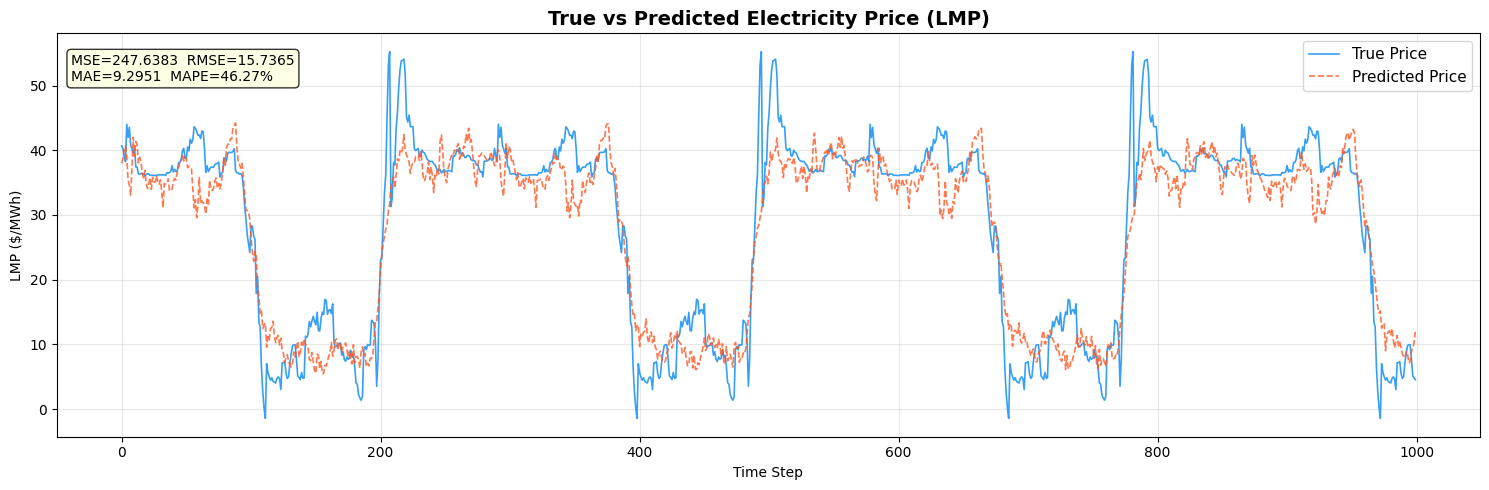

✅ Line plot saved
过滤后数据量: 5200583 / 5474304
true范围: -54.31 ~ 61.99
pred范围: -50.12 ~ 92.96


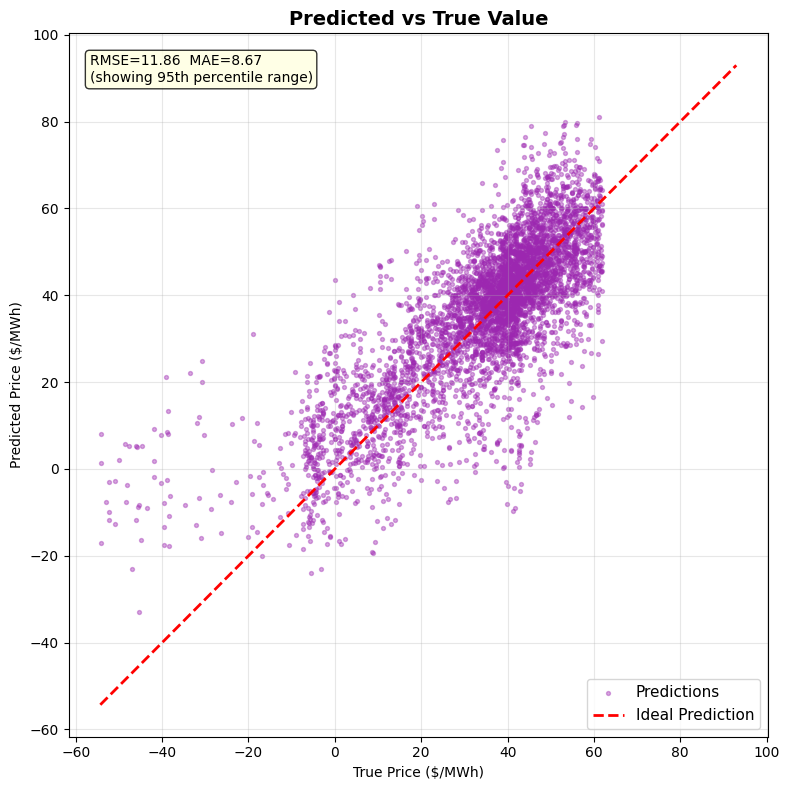

✅ Scatter plot saved
✅ CSV导出完成
保存路径: /kaggle/working/patchtst_prediction.csv
                 date  true_price  pred_price
0 2024-10-26 06:35:00    41.05517   37.994192
1 2024-10-26 06:40:00    40.67847   37.616721
2 2024-10-26 06:45:00    40.25564   36.642795
3 2024-10-26 06:50:00    39.10077   35.543039
4 2024-10-26 06:55:00    38.23166   35.081842
总行数: 19008


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==================== 加载数据 ====================
result_path = "/kaggle/working/PatchTST/PatchTST_supervised/results/electricity_PatchTST_custom_ftS_sl288_ll144_pl288_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_0/"
pred = np.load(result_path + "pred.npy")  # (19008, 288, 1)
true = np.load(result_path + "true.npy")  # (19008, 288, 1)

df = pd.read_csv("/kaggle/working/PatchTST/PatchTST_supervised/dataset/custom/data.csv")
lmp = df['LMP'].values
total = len(lmp)

num_train = int(total * 0.7)
num_val   = int(total * 0.1)
test_start = num_train + num_val
seq_len = 288

print(f"测试集起始: {test_start}, 总数据: {total}")

# ==================== 用每个样本的输入序列做反归一化 ====================
n_samples = pred.shape[0]
pred_inv_list = []
true_inv_list = []

for i in range(n_samples):
    # 每个样本对应的输入序列（用于计算mean和std）
    input_start = test_start + i - seq_len
    input_end   = test_start + i
    if input_end + 288 > total:
        break
    
    train_data = lmp[:num_train]
    mean = train_data.mean()
    std  = train_data.std()
    
    # 反归一化
    pred_inv = pred[i, :, 0] * std + mean
    true_inv = true[i, :, 0] * std + mean
    
    pred_inv_list.append(pred_inv)
    true_inv_list.append(true_inv)

pred_inv_array = np.array(pred_inv_list)
true_inv_array = np.array(true_inv_list)

pred_flat = pred_inv_array.reshape(-1)
true_flat = true_inv_array.reshape(-1)

print(f"\n反归一化后:")
print(f"true范围: {true_flat.min():.4f} ~ {true_flat.max():.4f}")
print(f"pred范围: {pred_flat.min():.4f} ~ {pred_flat.max():.4f}")

# ==================== 误差指标 ====================
mse  = mean_squared_error(true_flat, pred_flat)
mae  = mean_absolute_error(true_flat, pred_flat)
rmse = np.sqrt(mse)
# 排除true接近0的点再算MAPE
mask = np.abs(true_flat) > 1.0
mape = np.mean(np.abs((true_flat[mask] - pred_flat[mask]) / true_flat[mask])) * 100

print("\n========== 误差指标（真实电价单位）==========")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")

# ==================== 折线图 ====================
n_show = 1000
fig1, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(true_flat[:n_show], label='True Price', color='#2196F3', linewidth=1.2, alpha=0.9)
ax1.plot(pred_flat[:n_show], label='Predicted Price', color='#FF5722', linewidth=1.2, alpha=0.8, linestyle='--')
ax1.set_title('True vs Predicted Electricity Price (LMP)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time Step')
ax1.set_ylabel('LMP ($/MWh)')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
textstr = f'MSE={mse:.4f}  RMSE={rmse:.4f}\nMAE={mae:.4f}  MAPE={mape:.2f}%'
ax1.text(0.01, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('/kaggle/working/prediction_lineplot.svg', format='svg', bbox_inches='tight')
plt.show()
print("✅ Line plot saved")

import numpy as np
import matplotlib.pyplot as plt

# 去掉极端值，只保留95%分位数以内的数据来展示
p95 = np.percentile(np.abs(true_flat), 95)
mask = (np.abs(true_flat) <= p95) & (np.abs(pred_flat) <= p95 * 1.5)

true_plot = true_flat[mask]
pred_plot = pred_flat[mask]

print(f"过滤后数据量: {mask.sum()} / {len(true_flat)}")
print(f"true范围: {true_plot.min():.2f} ~ {true_plot.max():.2f}")
print(f"pred范围: {pred_plot.min():.2f} ~ {pred_plot.max():.2f}")

# 散点图
fig2, ax2 = plt.subplots(figsize=(8, 8))

sample_idx = np.random.choice(len(true_plot), size=min(5000, len(true_plot)), replace=False)
ax2.scatter(true_plot[sample_idx], pred_plot[sample_idx],
            alpha=0.4, s=8, color='#9C27B0', label='Predictions')

min_val = min(true_plot.min(), pred_plot.min())
max_val = max(true_plot.max(), pred_plot.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal Prediction')

# 误差指标标注
mse_plot  = np.mean((true_plot - pred_plot) ** 2)
mae_plot  = np.mean(np.abs(true_plot - pred_plot))
rmse_plot = np.sqrt(mse_plot)

textstr = f'RMSE={rmse_plot:.2f}  MAE={mae_plot:.2f}\n(showing 95th percentile range)'
ax2.text(0.03, 0.97, textstr, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))


ax2.set_title('Predicted vs True Value', fontsize=14, fontweight='bold')
ax2.set_xlabel('True Price ($/MWh)')
ax2.set_ylabel('Predicted Price ($/MWh)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/prediction_scatter.svg', format='svg', bbox_inches='tight')
plt.show()
print("✅ Scatter plot saved")

# ==================== 导出预测结果CSV ====================
# 只取最后一个预测点（避免重复预测）
pred_final = pred_inv_array[:, 0]
true_final = true_inv_array[:, 0]

# 读取时间列
date = pd.to_datetime(df['date'])

pred_len = 288

# PatchTST预测时间起点
start_index = test_start

time_index = date.iloc[start_index:start_index + len(pred_final)]

# 防止长度不一致
min_len = min(len(time_index), len(pred_final), len(true_final))

time_index = time_index[:min_len]
pred_final = pred_final[:min_len]
true_final = lmp[test_start:test_start + len(pred_final)]

# 构建结果表
result_df = pd.DataFrame({
    "date": time_index.values,
    "true_price": true_final,
    "pred_price": pred_final
})

# 保存CSV
csv_path = "/kaggle/working/patchtst_prediction.csv"
result_df.to_csv(csv_path, index=False)

print("✅ CSV导出完成")
print("保存路径:", csv_path)
print(result_df.head())
print("总行数:", len(result_df))

总滑动窗口样本数: 19008
每隔288步取样后天数: 66
实际使用天数: 66
预测电价范围: -18.01 ~ 124.30 $/MWh

开始运行 66 天的贪心调度...

========== 收益统计 ==========
总天数        : 66 天
日均净收益    : $10.34
最高单日收益  : $108.66
最低单日收益  : $-24.10
全期累计收益  : $682.52


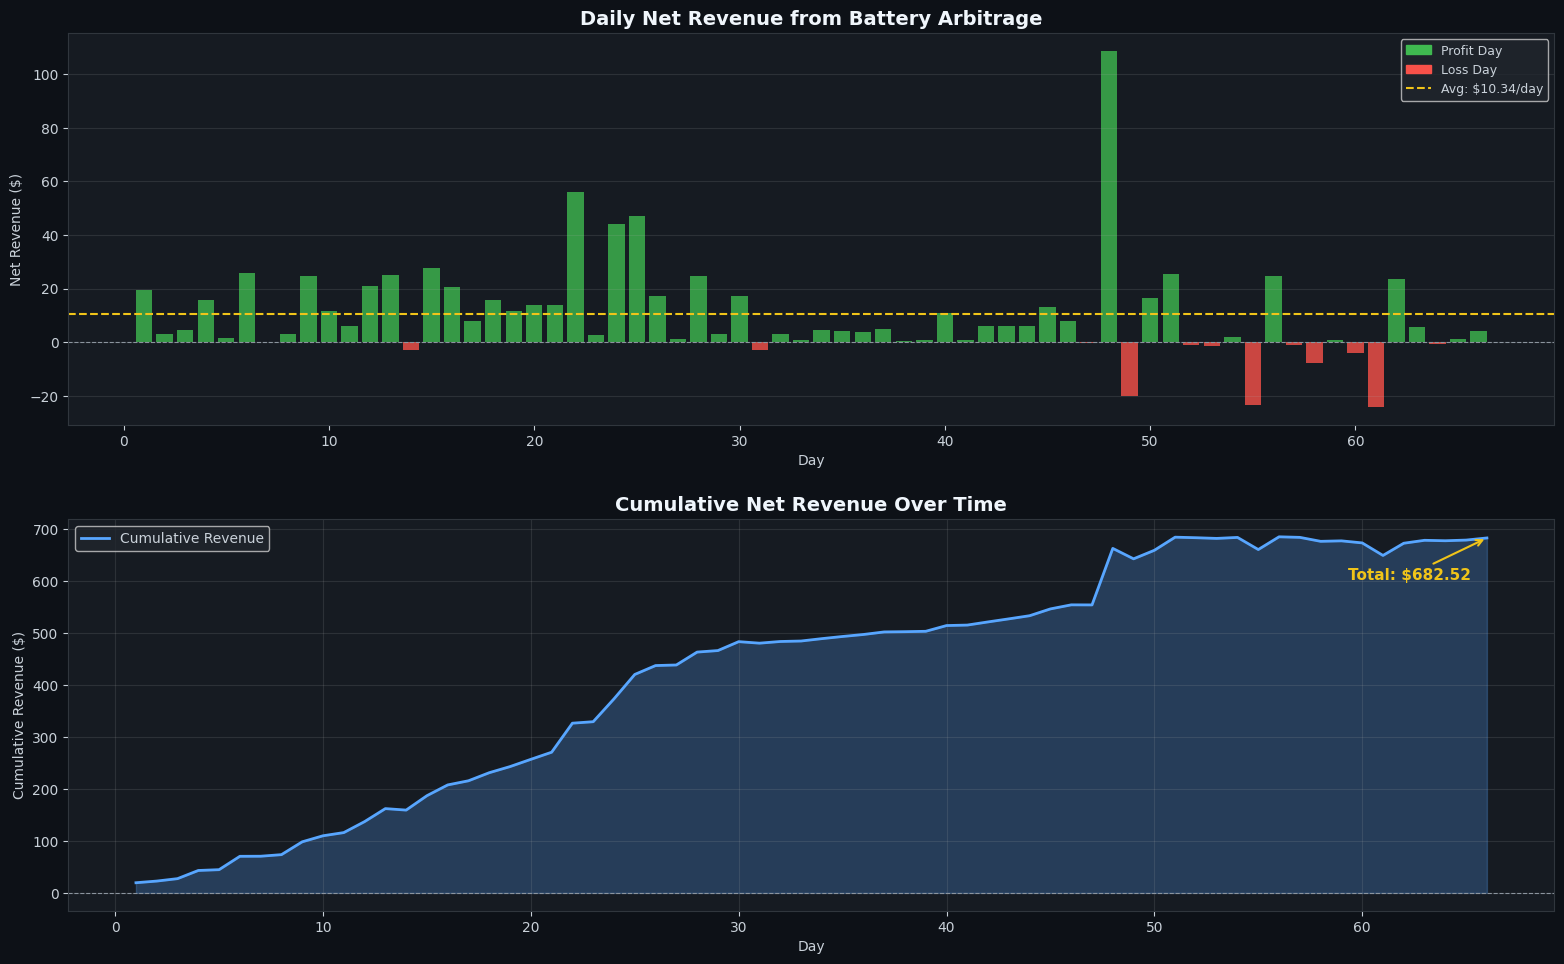

✅ 图已保存: /kaggle/working/battery_revenue.svg
✅ 文件确认存在: 87.5 KB


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==================== 电池参数 ====================
E_cap = 1.0
P_max = 0.25
eta_c = 0.95
eta_d = 0.95
SOC_min = 0.1
SOC_max = 0.9
SOC_init = 0.5
dt = 1/12  # 5分钟

C_inv = 300
Gamma_life = 3000
omega_base = 1.0

# ==================== 加载并反归一化 ====================
result_path = "/kaggle/working/PatchTST/PatchTST_supervised/results/electricity_PatchTST_custom_ftS_sl288_ll144_pl288_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_0/"
pred = np.load(result_path + "pred.npy")
true = np.load(result_path + "true.npy")

df = pd.read_csv("/kaggle/working/PatchTST/PatchTST_supervised/dataset/custom/data.csv")
lmp = df['LMP'].values
total = len(lmp)
num_train = int(total * 0.7)
num_val   = int(total * 0.1)
test_start = num_train + num_val
seq_len = 288

# ==================== 每隔288步取一个样本（真正的每天）====================
day_indices = list(range(0, pred.shape[0], 288))
print(f"总滑动窗口样本数: {pred.shape[0]}")
print(f"每隔288步取样后天数: {len(day_indices)}")

pred_days = []
true_days = []

for i in day_indices:
    input_start = test_start + i
    input_end   = input_start + seq_len
    if input_end + 288 > total:
        break
    input_seq = lmp[input_start:input_end]
    mean = np.mean(input_seq)
    std  = np.std(input_seq) + 1e-5
    pred_days.append(pred[i, :, 0] * std + mean)
    true_days.append(true[i, :, 0] * std + mean)

pred_prices = np.array(pred_days)
true_prices = np.array(true_days)
print(f"实际使用天数: {len(pred_prices)}")
print(f"预测电价范围: {pred_prices.min():.2f} ~ {pred_prices.max():.2f} $/MWh")

# ==================== 贪心调度函数 ====================
def battery_degradation(P_c, P_d):
    return omega_base * (C_inv / (2 * Gamma_life * E_cap)) * (eta_c * P_c + P_d / eta_d) * dt

def greedy_daily_dispatch(price_forecast, SOC_start=SOC_init):
    T = len(price_forecast)
    P_c = np.zeros(T)
    P_d = np.zeros(T)
    SOC = np.zeros(T + 1)
    SOC[0] = SOC_start

    price_high = np.percentile(price_forecast, 75)
    price_low  = np.percentile(price_forecast, 25)

    for t in range(T):
        soc_t = SOC[t]
        p = price_forecast[t]

        if p >= price_high and soc_t > SOC_min + 1e-3:
            max_discharge = min(P_max, (soc_t - SOC_min) * E_cap / dt * eta_d)
            P_d[t] = max(0, max_discharge)
            P_c[t] = 0
        elif p <= price_low and soc_t < SOC_max - 1e-3:
            max_charge = min(P_max, (SOC_max - soc_t) * E_cap / (dt * eta_c))
            P_c[t] = max(0, max_charge)
            P_d[t] = 0
        else:
            P_c[t] = 0
            P_d[t] = 0

        SOC[t+1] = soc_t + (eta_c * P_c[t] - P_d[t] / eta_d) * dt / E_cap
        SOC[t+1] = np.clip(SOC[t+1], SOC_min, SOC_max)

    return P_c, P_d, SOC

def calc_daily_profit(true_price, P_c, P_d):
    profit = 0
    for t in range(len(true_price)):
        revenue = true_price[t] * P_d[t] * dt
        cost    = true_price[t] * P_c[t] * dt
        deg     = battery_degradation(P_c[t], P_d[t])
        profit += revenue - cost - deg
    return profit

# ==================== 按天运行 ====================
n_days = len(pred_prices)
daily_profits = []
SOC_carry = SOC_init

print(f"\n开始运行 {n_days} 天的贪心调度...")
for day in range(n_days):
    P_c, P_d, SOC = greedy_daily_dispatch(pred_prices[day], SOC_start=SOC_carry)
    profit = calc_daily_profit(true_prices[day], P_c, P_d)
    daily_profits.append(profit)
    SOC_carry = SOC[-1]

daily_profits    = np.array(daily_profits)
cumulative_profits = np.cumsum(daily_profits)

print(f"\n========== 收益统计 ==========")
print(f"总天数        : {n_days} 天")
print(f"日均净收益    : ${np.mean(daily_profits):.2f}")
print(f"最高单日收益  : ${np.max(daily_profits):.2f}")
print(f"最低单日收益  : ${np.min(daily_profits):.2f}")
print(f"全期累计收益  : ${cumulative_profits[-1]:.2f}")

# ==================== 绘图 ====================
days = np.arange(1, n_days + 1)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    ax.title.set_color('#f0f6fc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

# 上图：每日净收益
colors = ['#3fb950' if p >= 0 else '#f85149' for p in daily_profits]
axes[0].bar(days, daily_profits, color=colors, alpha=0.8, width=0.8)
axes[0].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
axes[0].axhline(y=np.mean(daily_profits), color='#f0c419', linewidth=1.5, linestyle='--')
profit_patch = mpatches.Patch(color='#3fb950', label='Profit Day')
loss_patch   = mpatches.Patch(color='#f85149', label='Loss Day')
avg_line     = plt.Line2D([0],[0], color='#f0c419', linestyle='--',
                           label=f'Avg: ${np.mean(daily_profits):.2f}/day')
axes[0].legend(handles=[profit_patch, loss_patch, avg_line],
               fontsize=9, facecolor='#21262d', labelcolor='#c9d1d9')
axes[0].set_title('Daily Net Revenue from Battery Arbitrage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Net Revenue ($)')
axes[0].grid(True, alpha=0.15, axis='y')

# 下图：累计净收益
axes[1].fill_between(days, cumulative_profits, alpha=0.25, color='#58a6ff')
axes[1].plot(days, cumulative_profits, color='#58a6ff', linewidth=2.0, label='Cumulative Revenue')
axes[1].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
final_val = cumulative_profits[-1]
axes[1].annotate(f'Total: ${final_val:.2f}',
                 xy=(days[-1], final_val),
                 xytext=(-100, -30 if final_val > 0 else 30),
                 textcoords='offset points',
                 color='#f0c419', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#f0c419', lw=1.5))
axes[1].set_title('Cumulative Net Revenue Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative Revenue ($)')
axes[1].legend(fontsize=10, facecolor='#21262d', labelcolor='#c9d1d9')
axes[1].grid(True, alpha=0.15)

plt.tight_layout(pad=2.0)
plt.savefig('/kaggle/working/battery_revenue.svg', format='svg',
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ 图已保存: /kaggle/working/battery_revenue.svg")

# 确认文件存在
import os
if os.path.exists('/kaggle/working/battery_revenue.svg'):
    size = os.path.getsize('/kaggle/working/battery_revenue.svg') / 1024
    print(f"✅ 文件确认存在: {size:.1f} KB")

实际使用天数: 65
预测电价范围: -0.74 ~ 48.55 $/MWh

开始运行 65 天的贪心调度...

========== TST 收益统计 ==========
总天数        : 65 天
日均净收益    : $23.90
最高单日收益  : $36.47
最低单日收益  : $22.83
全期累计收益  : $1553.34


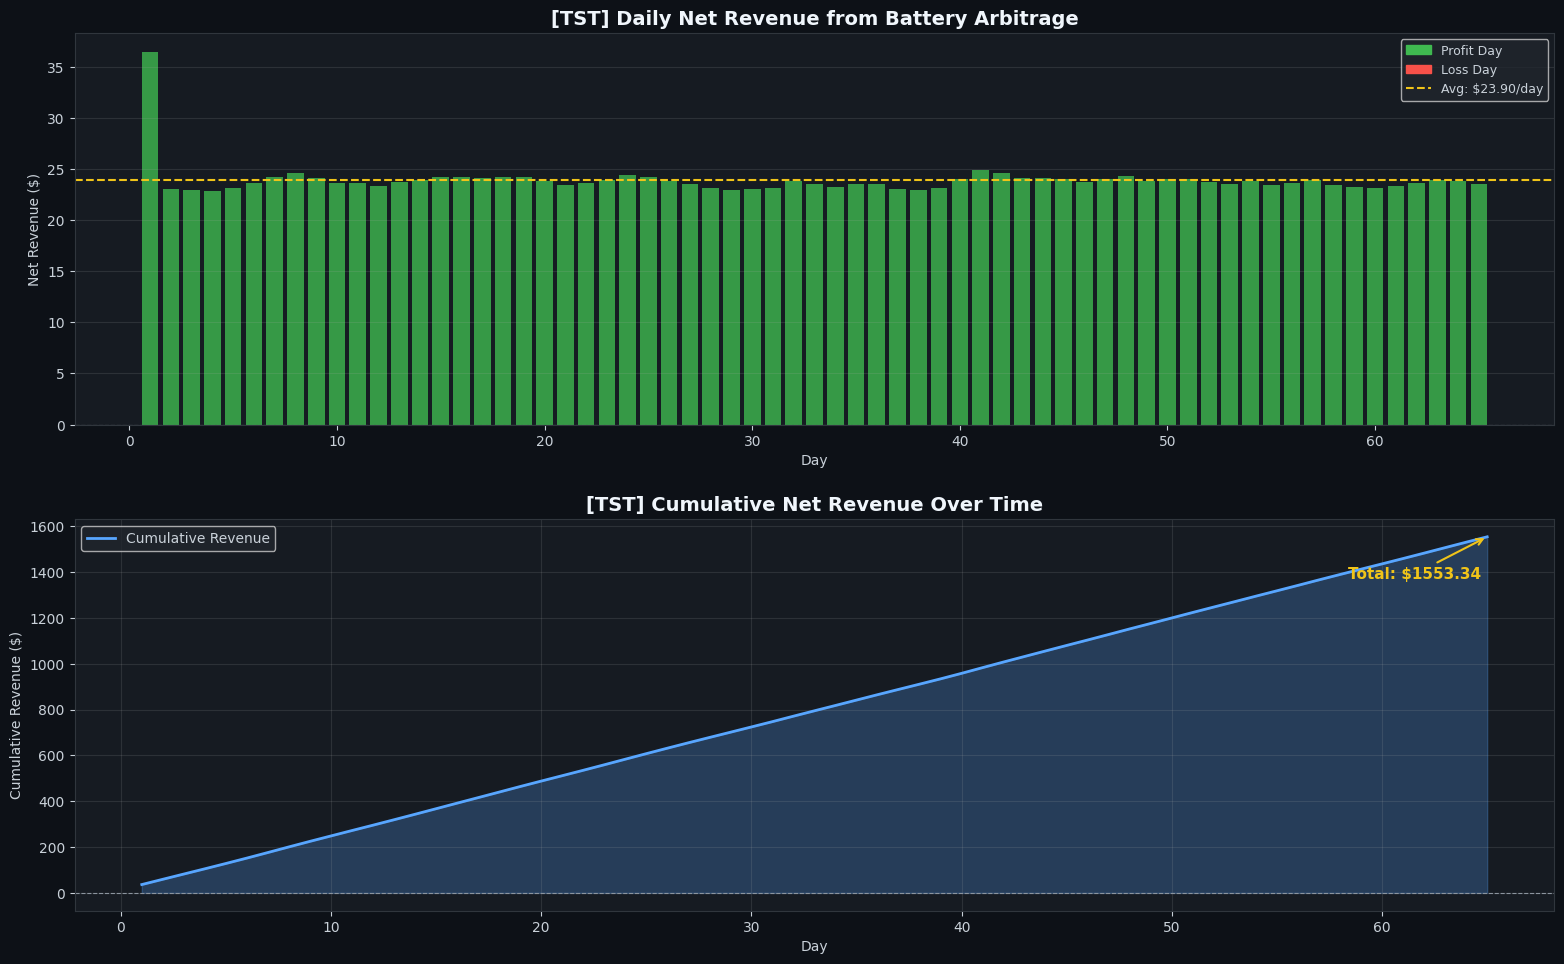

✅ 图已保存: /kaggle/working/battery_revenue_TST.svg


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==================== 电池参数 ====================
E_cap = 1.0
P_max = 0.25
eta_c = 0.95
eta_d = 0.95
SOC_min = 0.1
SOC_max = 0.9
SOC_init = 0.5
dt = 1/12  # 5分钟
C_inv = 300
Gamma_life = 3000
omega_base = 1.0

# ==================== 加载CSV（替换原来的.npy加载+反归一化）====================
df = pd.read_csv('/kaggle/input/datasets/chongwentang/tst-prediction-new/tst_prediction_results (1).csv')
true_vals = df['true_LMP'].values
pred_vals = df['predicted_LMP'].values

# ==================== 每隔288步取一个样本（与PatchTST逻辑一致）====================
points_per_day = 288
pred_days = []
true_days = []

for i in range(0, len(true_vals), points_per_day):
    if i + points_per_day > len(true_vals):
        break
    pred_days.append(pred_vals[i : i + points_per_day])
    true_days.append(true_vals[i : i + points_per_day])

pred_days = pred_days[:-1]
true_days = true_days[:-1]

pred_prices = np.array(pred_days)
true_prices = np.array(true_days)

print(f"实际使用天数: {len(pred_prices)}")
print(f"预测电价范围: {pred_prices.min():.2f} ~ {pred_prices.max():.2f} $/MWh")

# ==================== 贪心调度函数 ====================
def battery_degradation(P_c, P_d):
    return omega_base * (C_inv / (2 * Gamma_life * E_cap)) * (eta_c * P_c + P_d / eta_d) * dt

def greedy_daily_dispatch(price_forecast, SOC_start=SOC_init):
    T = len(price_forecast)
    P_c = np.zeros(T)
    P_d = np.zeros(T)
    SOC = np.zeros(T + 1)
    SOC[0] = SOC_start
    price_high = np.percentile(price_forecast, 75)
    price_low  = np.percentile(price_forecast, 25)
    for t in range(T):
        soc_t = SOC[t]
        p = price_forecast[t]
        if p >= price_high and soc_t > SOC_min + 1e-3:
            max_discharge = min(P_max, (soc_t - SOC_min) * E_cap / dt * eta_d)
            P_d[t] = max(0, max_discharge)
            P_c[t] = 0
        elif p <= price_low and soc_t < SOC_max - 1e-3:
            max_charge = min(P_max, (SOC_max - soc_t) * E_cap / (dt * eta_c))
            P_c[t] = max(0, max_charge)
            P_d[t] = 0
        else:
            P_c[t] = 0
            P_d[t] = 0
        SOC[t+1] = soc_t + (eta_c * P_c[t] - P_d[t] / eta_d) * dt / E_cap
        SOC[t+1] = np.clip(SOC[t+1], SOC_min, SOC_max)
    return P_c, P_d, SOC

def calc_daily_profit(true_price, P_c, P_d):
    profit = 0
    for t in range(len(true_price)):
        revenue = true_price[t] * P_d[t] * dt
        cost    = true_price[t] * P_c[t] * dt
        deg     = battery_degradation(P_c[t], P_d[t])
        profit += revenue - cost - deg
    return profit

# ==================== 按天运行 ====================
n_days = len(pred_prices)
daily_profits = []
SOC_carry = SOC_init

print(f"\n开始运行 {n_days} 天的贪心调度...")
for day in range(n_days):
    P_c, P_d, SOC = greedy_daily_dispatch(pred_prices[day], SOC_start=SOC_carry)
    profit = calc_daily_profit(true_prices[day], P_c, P_d)
    daily_profits.append(profit)
    SOC_carry = SOC[-1]

daily_profits      = np.array(daily_profits)
cumulative_profits = np.cumsum(daily_profits)

print(f"\n========== TST 收益统计 ==========")
print(f"总天数        : {n_days} 天")
print(f"日均净收益    : ${np.mean(daily_profits):.2f}")
print(f"最高单日收益  : ${np.max(daily_profits):.2f}")
print(f"最低单日收益  : ${np.min(daily_profits):.2f}")
print(f"全期累计收益  : ${cumulative_profits[-1]:.2f}")

# ==================== 绘图 ====================
days = np.arange(1, n_days + 1)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    ax.title.set_color('#f0f6fc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

colors = ['#3fb950' if p >= 0 else '#f85149' for p in daily_profits]
axes[0].bar(days, daily_profits, color=colors, alpha=0.8, width=0.8)
axes[0].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
axes[0].axhline(y=np.mean(daily_profits), color='#f0c419', linewidth=1.5, linestyle='--')
profit_patch = mpatches.Patch(color='#3fb950', label='Profit Day')
loss_patch   = mpatches.Patch(color='#f85149', label='Loss Day')
avg_line     = plt.Line2D([0],[0], color='#f0c419', linestyle='--',
                           label=f'Avg: ${np.mean(daily_profits):.2f}/day')
axes[0].legend(handles=[profit_patch, loss_patch, avg_line],
               fontsize=9, facecolor='#21262d', labelcolor='#c9d1d9')
axes[0].set_title('[TST] Daily Net Revenue from Battery Arbitrage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Net Revenue ($)')
axes[0].grid(True, alpha=0.15, axis='y')

axes[1].fill_between(days, cumulative_profits, alpha=0.25, color='#58a6ff')
axes[1].plot(days, cumulative_profits, color='#58a6ff', linewidth=2.0, label='Cumulative Revenue')
axes[1].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
final_val = cumulative_profits[-1]
axes[1].annotate(f'Total: ${final_val:.2f}',
                 xy=(days[-1], final_val),
                 xytext=(-100, -30 if final_val > 0 else 30),
                 textcoords='offset points',
                 color='#f0c419', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#f0c419', lw=1.5))
axes[1].set_title('[TST] Cumulative Net Revenue Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative Revenue ($)')
axes[1].legend(fontsize=10, facecolor='#21262d', labelcolor='#c9d1d9')
axes[1].grid(True, alpha=0.15)

plt.tight_layout(pad=2.0)
plt.savefig('/kaggle/working/battery_revenue_TST.svg', format='svg',
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ 图已保存: /kaggle/working/battery_revenue_TST.svg")
tst_daily_profits = daily_profits

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

result_path = "/kaggle/working/PatchTST/PatchTST_supervised/results/electricity_PatchTST_custom_ftS_sl288_ll144_pl288_dm128_nh16_el3_dl1_df256_fc1_ebtimeF_dtTrue_test_0/"
pred = np.load(result_path + "pred.npy")
true = np.load(result_path + "true.npy")

df = pd.read_csv("/kaggle/input/datasets/chongwentang/tst-prediction-new/tst_prediction_results (1).csv")
lmp = df['true_LMP'].values
total = len(lmp)

num_train = int(total * 0.7)
num_val   = int(total * 0.1)
test_start = num_train + num_val

# ✅ 用和PatchTST完全一样的scaler：只在训练集上fit
scaler = StandardScaler()
train_data = lmp[:num_train].reshape(-1, 1)
scaler.fit(train_data)  # 关键：只用训练集fit

# ✅ 反归一化
pred_flat = scaler.inverse_transform(pred[:, :, 0].reshape(-1, 1)).reshape(-1)
true_flat = scaler.inverse_transform(true[:, :, 0].reshape(-1, 1)).reshape(-1)

# 对齐时间戳
seq_len = 288
ts_start = test_start             # ✅ 直接从测试集起始对齐
timestamps = df['date'].values
min_len = min(len(pred_flat), len(true_flat), len(timestamps) - ts_start)

result_df = pd.DataFrame({
    'date'          : timestamps[ts_start : ts_start + min_len],
    'true_LMP'      : true_flat[:min_len],
    'predicted_LMP' : pred_flat[:min_len],
    'error'         : pred_flat[:min_len] - true_flat[:min_len],
    'abs_error'     : np.abs(pred_flat[:min_len] - true_flat[:min_len])
})

result_df.to_csv('/kaggle/working/prediction_results.csv', index=False)
print(result_df.head(10))

                        date   true_LMP  predicted_LMP     error  abs_error
0  2024-12-18 22:25:00+00:00  33.968403      32.977627 -0.990776   0.990776
1  2024-12-18 22:30:00+00:00  33.812332      33.218082 -0.594250   0.594250
2  2024-12-18 22:35:00+00:00  33.386066      33.694809  0.308743   0.308743
3  2024-12-18 22:40:00+00:00  33.065277      33.976303  0.911026   0.911026
4  2024-12-18 22:45:00+00:00  35.198765      33.400826 -1.797939   1.797939
5  2024-12-18 22:50:00+00:00  34.445789      32.016552 -2.429237   2.429237
6  2024-12-18 22:55:00+00:00  35.028286      31.710325 -3.317961   3.317961
7  2024-12-18 23:00:00+00:00  34.007370      31.159683 -2.847687   2.847687
8  2024-12-18 23:05:00+00:00  33.796467      32.688293 -1.108173   1.108173
9  2024-12-18 23:10:00+00:00  33.544693      34.461670  0.916977   0.916977


实际使用天数: 65
预测电价范围: 32.81 ~ 37.08 $/MWh

开始运行 65 天的贪心调度...

========== ARIMA 收益统计 ==========
总天数        : 65 天
日均净收益    : $-10.44
最高单日收益  : $22.99
最低单日收益  : $-18.26
全期累计收益  : $-678.54


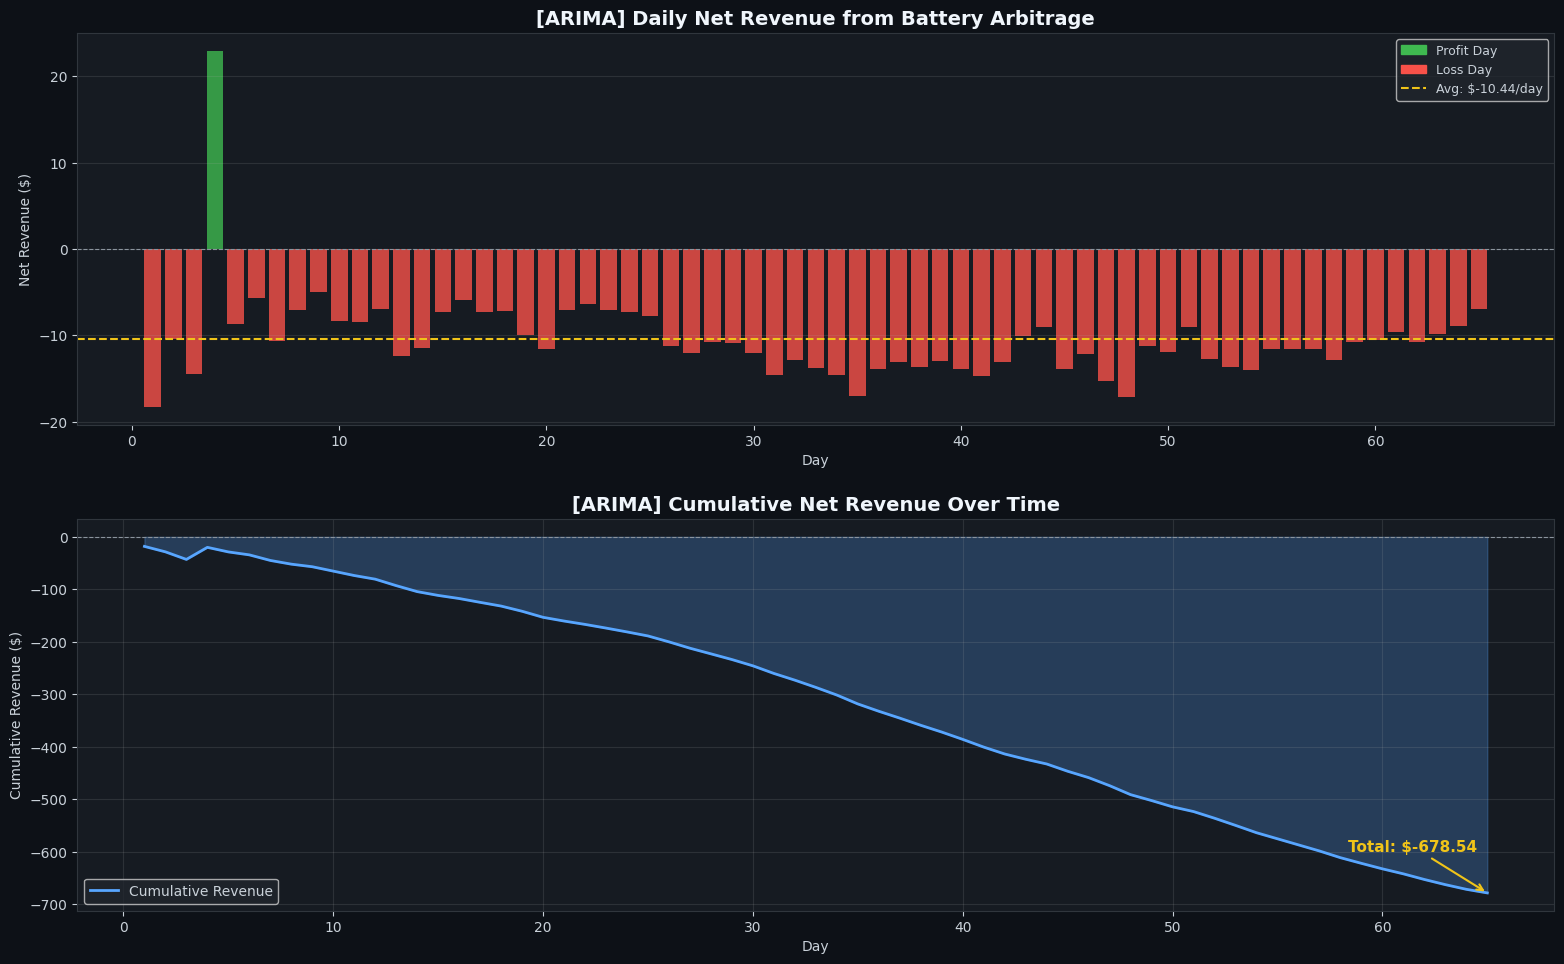

✅ 图已保存: /kaggle/working/battery_revenue_ARIMA.svg


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==================== 电池参数 ====================
E_cap = 1.0
P_max = 0.25
eta_c = 0.95
eta_d = 0.95
SOC_min = 0.1
SOC_max = 0.9
SOC_init = 0.5
dt = 1/12  # 5分钟
C_inv = 300
Gamma_life = 3000
omega_base = 1.0

# ==================== 加载CSV（替换原来的.npy加载+反归一化）====================
df = pd.read_csv('/kaggle/input/datasets/chongwentang/arima-predictions-new/arima_predictions - .csv')
true_vals = df['True_Value'].values
pred_vals = df['ARIMA_Predicted'].values

# ==================== 每隔288步取一个样本（与PatchTST逻辑一致）====================
points_per_day = 288
pred_days = []
true_days = []

for i in range(0, len(true_vals), points_per_day):
    if i + points_per_day > len(true_vals):
        break
    pred_days.append(pred_vals[i : i + points_per_day])
    true_days.append(true_vals[i : i + points_per_day])

# 舍弃最后一天（对齐66天）
pred_days = pred_days[:-1]
true_days = true_days[:-1]

pred_prices = np.array(pred_days)
true_prices = np.array(true_days)

print(f"实际使用天数: {len(pred_prices)}")
print(f"预测电价范围: {pred_prices.min():.2f} ~ {pred_prices.max():.2f} $/MWh")

# ==================== 贪心调度函数 ====================
def battery_degradation(P_c, P_d):
    return omega_base * (C_inv / (2 * Gamma_life * E_cap)) * (eta_c * P_c + P_d / eta_d) * dt

def greedy_daily_dispatch(price_forecast, SOC_start=SOC_init):
    T = len(price_forecast)
    P_c = np.zeros(T)
    P_d = np.zeros(T)
    SOC = np.zeros(T + 1)
    SOC[0] = SOC_start
    price_high = np.percentile(price_forecast, 75)
    price_low  = np.percentile(price_forecast, 25)
    for t in range(T):
        soc_t = SOC[t]
        p = price_forecast[t]
        if p >= price_high and soc_t > SOC_min + 1e-3:
            max_discharge = min(P_max, (soc_t - SOC_min) * E_cap / dt * eta_d)
            P_d[t] = max(0, max_discharge)
            P_c[t] = 0
        elif p <= price_low and soc_t < SOC_max - 1e-3:
            max_charge = min(P_max, (SOC_max - soc_t) * E_cap / (dt * eta_c))
            P_c[t] = max(0, max_charge)
            P_d[t] = 0
        else:
            P_c[t] = 0
            P_d[t] = 0
        SOC[t+1] = soc_t + (eta_c * P_c[t] - P_d[t] / eta_d) * dt / E_cap
        SOC[t+1] = np.clip(SOC[t+1], SOC_min, SOC_max)
    return P_c, P_d, SOC

def calc_daily_profit(true_price, P_c, P_d):
    profit = 0
    for t in range(len(true_price)):
        revenue = true_price[t] * P_d[t] * dt
        cost    = true_price[t] * P_c[t] * dt
        deg     = battery_degradation(P_c[t], P_d[t])
        profit += revenue - cost - deg
    return profit

# ==================== 按天运行 ====================
n_days = len(pred_prices)
daily_profits = []
SOC_carry = SOC_init

print(f"\n开始运行 {n_days} 天的贪心调度...")
for day in range(n_days):
    P_c, P_d, SOC = greedy_daily_dispatch(pred_prices[day], SOC_start=SOC_carry)
    profit = calc_daily_profit(true_prices[day], P_c, P_d)
    daily_profits.append(profit)
    SOC_carry = SOC[-1]

daily_profits      = np.array(daily_profits)
cumulative_profits = np.cumsum(daily_profits)

print(f"\n========== ARIMA 收益统计 ==========")
print(f"总天数        : {n_days} 天")
print(f"日均净收益    : ${np.mean(daily_profits):.2f}")
print(f"最高单日收益  : ${np.max(daily_profits):.2f}")
print(f"最低单日收益  : ${np.min(daily_profits):.2f}")
print(f"全期累计收益  : ${cumulative_profits[-1]:.2f}")

# ==================== 绘图 ====================
days = np.arange(1, n_days + 1)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    ax.title.set_color('#f0f6fc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

colors = ['#3fb950' if p >= 0 else '#f85149' for p in daily_profits]
axes[0].bar(days, daily_profits, color=colors, alpha=0.8, width=0.8)
axes[0].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
axes[0].axhline(y=np.mean(daily_profits), color='#f0c419', linewidth=1.5, linestyle='--')
profit_patch = mpatches.Patch(color='#3fb950', label='Profit Day')
loss_patch   = mpatches.Patch(color='#f85149', label='Loss Day')
avg_line     = plt.Line2D([0],[0], color='#f0c419', linestyle='--',
                           label=f'Avg: ${np.mean(daily_profits):.2f}/day')
axes[0].legend(handles=[profit_patch, loss_patch, avg_line],
               fontsize=9, facecolor='#21262d', labelcolor='#c9d1d9')
axes[0].set_title('[ARIMA] Daily Net Revenue from Battery Arbitrage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Net Revenue ($)')
axes[0].grid(True, alpha=0.15, axis='y')

axes[1].fill_between(days, cumulative_profits, alpha=0.25, color='#58a6ff')
axes[1].plot(days, cumulative_profits, color='#58a6ff', linewidth=2.0, label='Cumulative Revenue')
axes[1].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
final_val = cumulative_profits[-1]
axes[1].annotate(f'Total: ${final_val:.2f}',
                 xy=(days[-1], final_val),
                 xytext=(-100, -30 if final_val > 0 else 30),
                 textcoords='offset points',
                 color='#f0c419', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#f0c419', lw=1.5))
axes[1].set_title('[ARIMA] Cumulative Net Revenue Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative Revenue ($)')
axes[1].legend(fontsize=10, facecolor='#21262d', labelcolor='#c9d1d9')
axes[1].grid(True, alpha=0.15)

plt.tight_layout(pad=2.0)
plt.savefig('/kaggle/working/battery_revenue_ARIMA.svg', format='svg',
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ 图已保存: /kaggle/working/battery_revenue_ARIMA.svg")
arima_daily_profits = daily_profits

实际使用天数: 65
预测电价范围: -265.83 ~ 921.25 $/MWh

开始运行 65 天的贪心调度...

========== LTSM 收益统计 ==========
总天数        : 65 天
日均净收益    : $24.78
最高单日收益  : $56.89
最低单日收益  : $-26.28
全期累计收益  : $1610.58


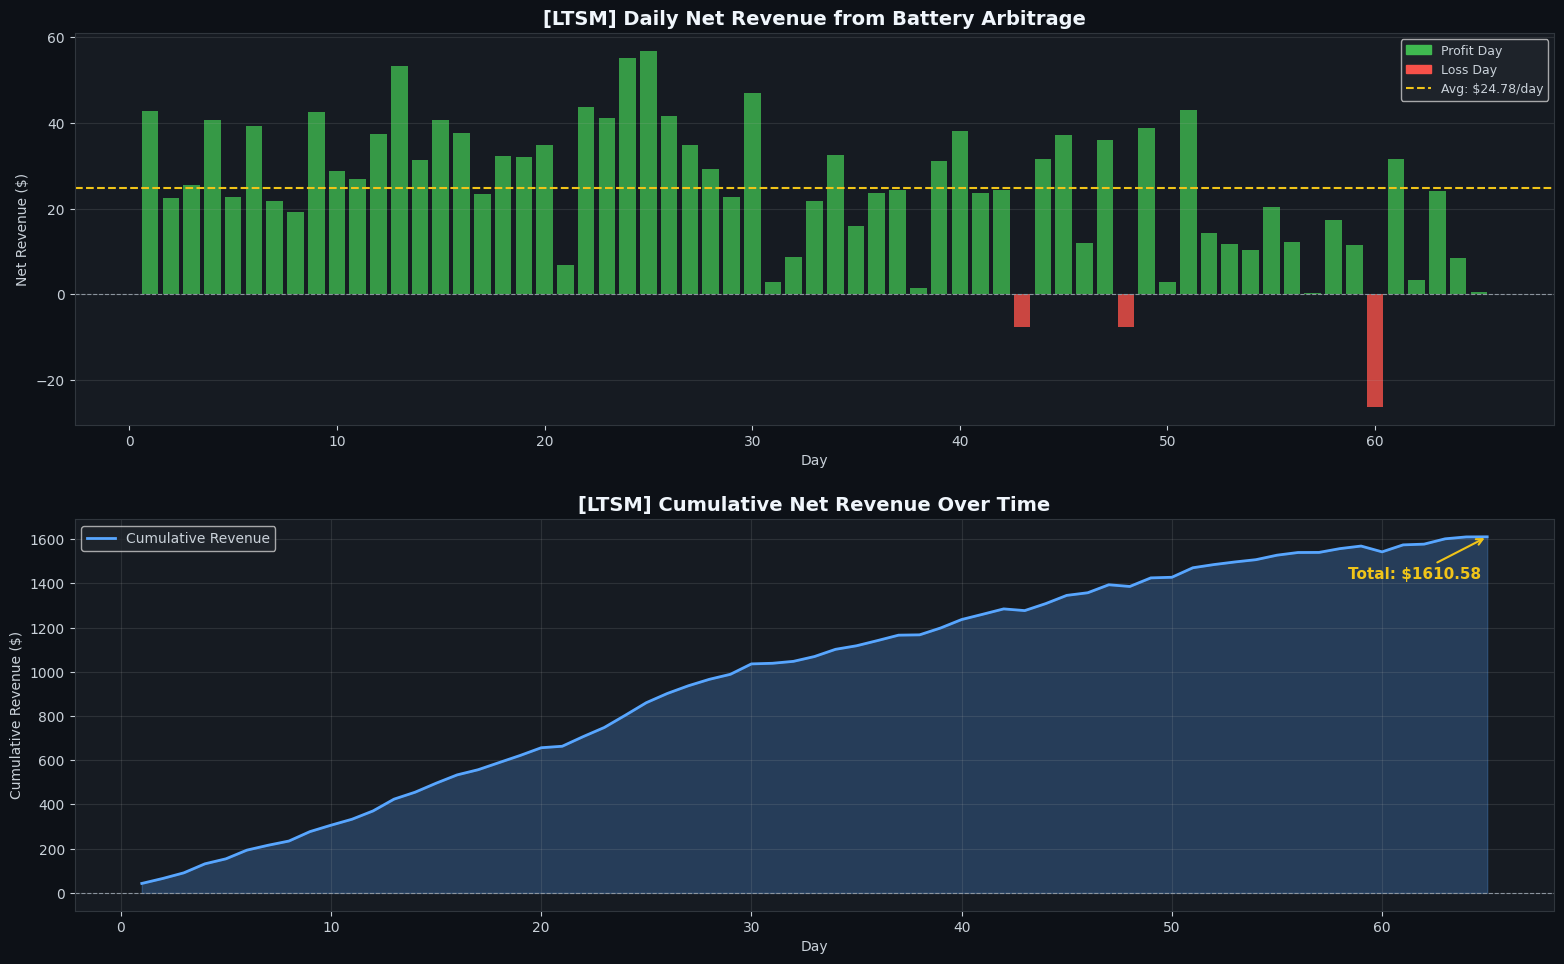

✅ 图已保存: /kaggle/working/battery_revenue_LTSM.svg


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==================== 电池参数 ====================
E_cap = 1.0
P_max = 0.25
eta_c = 0.95
eta_d = 0.95
SOC_min = 0.1
SOC_max = 0.9
SOC_init = 0.5
dt = 1/12  # 5分钟
C_inv = 300
Gamma_life = 3000
omega_base = 1.0

# ==================== 加载CSV（替换原来的.npy加载+反归一化）====================
df = pd.read_csv('/kaggle/input/datasets/chongwentang/lstm-predictions-new/lstm_predictions(3).csv')
true_vals = df['True_Value'].values
pred_vals = df['LSTM_Predicted'].values

# ==================== 每隔288步取一个样本（与PatchTST逻辑一致）====================
points_per_day = 288
pred_days = []
true_days = []

for i in range(0, len(true_vals), points_per_day):
    if i + points_per_day > len(true_vals):
        break
    pred_days.append(pred_vals[i : i + points_per_day])
    true_days.append(true_vals[i : i + points_per_day])

# 舍弃最后一天（对齐66天）
pred_days = pred_days[:-1]
true_days = true_days[:-1]

pred_prices = np.array(pred_days)
true_prices = np.array(true_days)

print(f"实际使用天数: {len(pred_prices)}")
print(f"预测电价范围: {pred_prices.min():.2f} ~ {pred_prices.max():.2f} $/MWh")

# ==================== 贪心调度函数 ====================
def battery_degradation(P_c, P_d):
    return omega_base * (C_inv / (2 * Gamma_life * E_cap)) * (eta_c * P_c + P_d / eta_d) * dt

def greedy_daily_dispatch(price_forecast, SOC_start=SOC_init):
    T = len(price_forecast)
    P_c = np.zeros(T)
    P_d = np.zeros(T)
    SOC = np.zeros(T + 1)
    SOC[0] = SOC_start
    price_high = np.percentile(price_forecast, 75)
    price_low  = np.percentile(price_forecast, 25)
    for t in range(T):
        soc_t = SOC[t]
        p = price_forecast[t]
        if p >= price_high and soc_t > SOC_min + 1e-3:
            max_discharge = min(P_max, (soc_t - SOC_min) * E_cap / dt * eta_d)
            P_d[t] = max(0, max_discharge)
            P_c[t] = 0
        elif p <= price_low and soc_t < SOC_max - 1e-3:
            max_charge = min(P_max, (SOC_max - soc_t) * E_cap / (dt * eta_c))
            P_c[t] = max(0, max_charge)
            P_d[t] = 0
        else:
            P_c[t] = 0
            P_d[t] = 0
        SOC[t+1] = soc_t + (eta_c * P_c[t] - P_d[t] / eta_d) * dt / E_cap
        SOC[t+1] = np.clip(SOC[t+1], SOC_min, SOC_max)
    return P_c, P_d, SOC

def calc_daily_profit(true_price, P_c, P_d):
    profit = 0
    for t in range(len(true_price)):
        revenue = true_price[t] * P_d[t] * dt
        cost    = true_price[t] * P_c[t] * dt
        deg     = battery_degradation(P_c[t], P_d[t])
        profit += revenue - cost - deg
    return profit

# ==================== 按天运行 ====================
n_days = len(pred_prices)
daily_profits = []
SOC_carry = SOC_init

print(f"\n开始运行 {n_days} 天的贪心调度...")
for day in range(n_days):
    P_c, P_d, SOC = greedy_daily_dispatch(pred_prices[day], SOC_start=SOC_carry)
    profit = calc_daily_profit(true_prices[day], P_c, P_d)
    daily_profits.append(profit)
    SOC_carry = SOC[-1]

daily_profits      = np.array(daily_profits)
cumulative_profits = np.cumsum(daily_profits)

print(f"\n========== LTSM 收益统计 ==========")
print(f"总天数        : {n_days} 天")
print(f"日均净收益    : ${np.mean(daily_profits):.2f}")
print(f"最高单日收益  : ${np.max(daily_profits):.2f}")
print(f"最低单日收益  : ${np.min(daily_profits):.2f}")
print(f"全期累计收益  : ${cumulative_profits[-1]:.2f}")

# ==================== 绘图 ====================
days = np.arange(1, n_days + 1)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    ax.xaxis.label.set_color('#c9d1d9')
    ax.yaxis.label.set_color('#c9d1d9')
    ax.title.set_color('#f0f6fc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

colors = ['#3fb950' if p >= 0 else '#f85149' for p in daily_profits]
axes[0].bar(days, daily_profits, color=colors, alpha=0.8, width=0.8)
axes[0].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
axes[0].axhline(y=np.mean(daily_profits), color='#f0c419', linewidth=1.5, linestyle='--')
profit_patch = mpatches.Patch(color='#3fb950', label='Profit Day')
loss_patch   = mpatches.Patch(color='#f85149', label='Loss Day')
avg_line     = plt.Line2D([0],[0], color='#f0c419', linestyle='--',
                           label=f'Avg: ${np.mean(daily_profits):.2f}/day')
axes[0].legend(handles=[profit_patch, loss_patch, avg_line],
               fontsize=9, facecolor='#21262d', labelcolor='#c9d1d9')
axes[0].set_title('[LTSM] Daily Net Revenue from Battery Arbitrage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Net Revenue ($)')
axes[0].grid(True, alpha=0.15, axis='y')

axes[1].fill_between(days, cumulative_profits, alpha=0.25, color='#58a6ff')
axes[1].plot(days, cumulative_profits, color='#58a6ff', linewidth=2.0, label='Cumulative Revenue')
axes[1].axhline(y=0, color='#8b949e', linewidth=0.8, linestyle='--')
final_val = cumulative_profits[-1]
axes[1].annotate(f'Total: ${final_val:.2f}',
                 xy=(days[-1], final_val),
                 xytext=(-100, -30 if final_val > 0 else 30),
                 textcoords='offset points',
                 color='#f0c419', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#f0c419', lw=1.5))
axes[1].set_title('[LTSM] Cumulative Net Revenue Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Cumulative Revenue ($)')
axes[1].legend(fontsize=10, facecolor='#21262d', labelcolor='#c9d1d9')
axes[1].grid(True, alpha=0.15)

plt.tight_layout(pad=2.0)
plt.savefig('/kaggle/working/battery_revenue_LTSM.svg', format='svg',
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ 图已保存: /kaggle/working/battery_revenue_LTSM.svg")
lstm_daily_profits = daily_profits

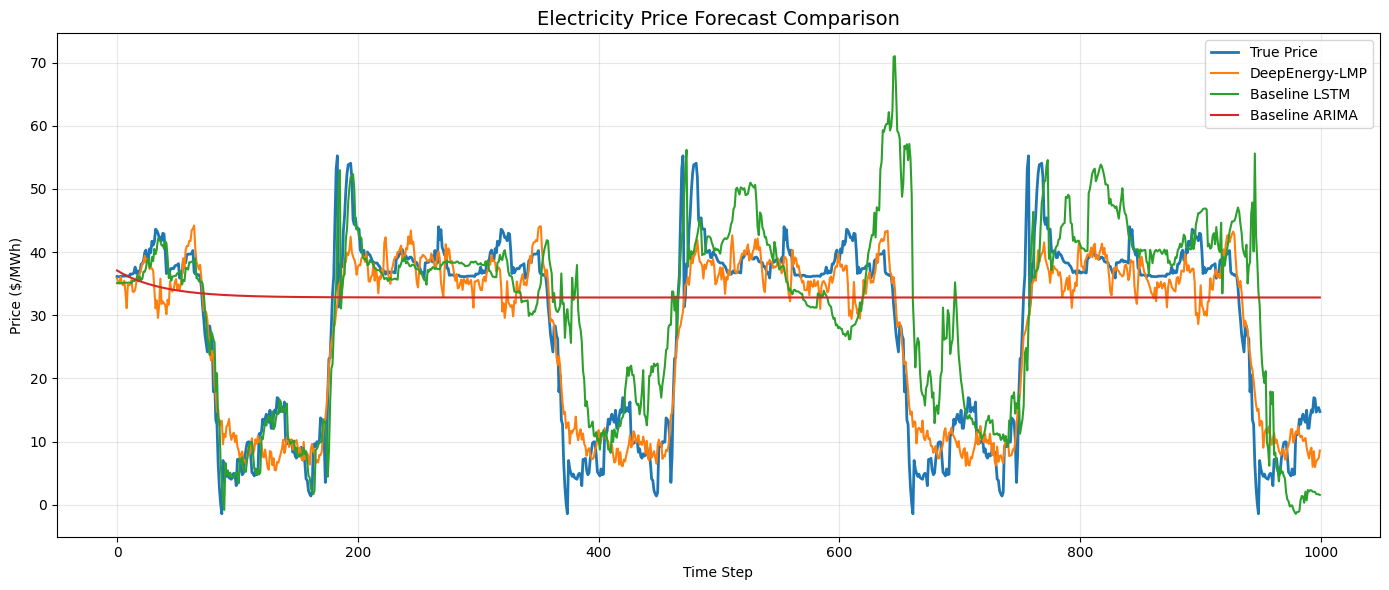

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# ==================== 读取数据 ====================

patch = pd.read_csv("/kaggle/input/datasets/chongwentang/tst-prediction-new/tst_prediction_results (1).csv")
lstm  = pd.read_csv("/kaggle/input/datasets/chongwentang/lstm-predictions-new/lstm_predictions(3).csv")
arima = pd.read_csv("/kaggle/input/datasets/chongwentang/arima-predictions-new/arima_predictions - .csv")

# ==================== 合并数据 ====================

df = pd.DataFrame({
    "time": patch["date"],
    "true": patch["true_LMP"],
    "PatchTST": patch["predicted_LMP"],
    "LSTM": lstm["LSTM_Predicted"],
    "ARIMA": arima["ARIMA_Predicted"]
})

# ==================== 只画一小段（否则太密） ====================

plot_points = 1000

df_plot = df.iloc[:plot_points]

# ==================== 绘图 ====================

plt.figure(figsize=(14,6))

plt.plot(df_plot["true"], label="True Price", linewidth=2)
plt.plot(df_plot["PatchTST"], label="DeepEnergy-LMP")
plt.plot(df_plot["LSTM"], label="Baseline LSTM")
plt.plot(df_plot["ARIMA"], label="Baseline ARIMA")

plt.title("Electricity Price Forecast Comparison", fontsize=14)
plt.xlabel("Time Step")
plt.ylabel("Price ($/MWh)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


plt.savefig("/kaggle/working/model_comparison.svg", format="svg", bbox_inches="tight")
plt.show()

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

true = df["true"]

models = ["PatchTST","LSTM","ARIMA"]

for m in models:
    
    mae = mean_absolute_error(true, df[m])
    rmse = np.sqrt(mean_squared_error(true, df[m]))
    
    print(f"{m}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print()

PatchTST
MAE : 4.040850065316501
RMSE: 5.566371650419102

LSTM
MAE : 16.072102541113622
RMSE: 23.766064025298885

ARIMA
MAE : 12.316137658039816
RMSE: 15.293253079306059



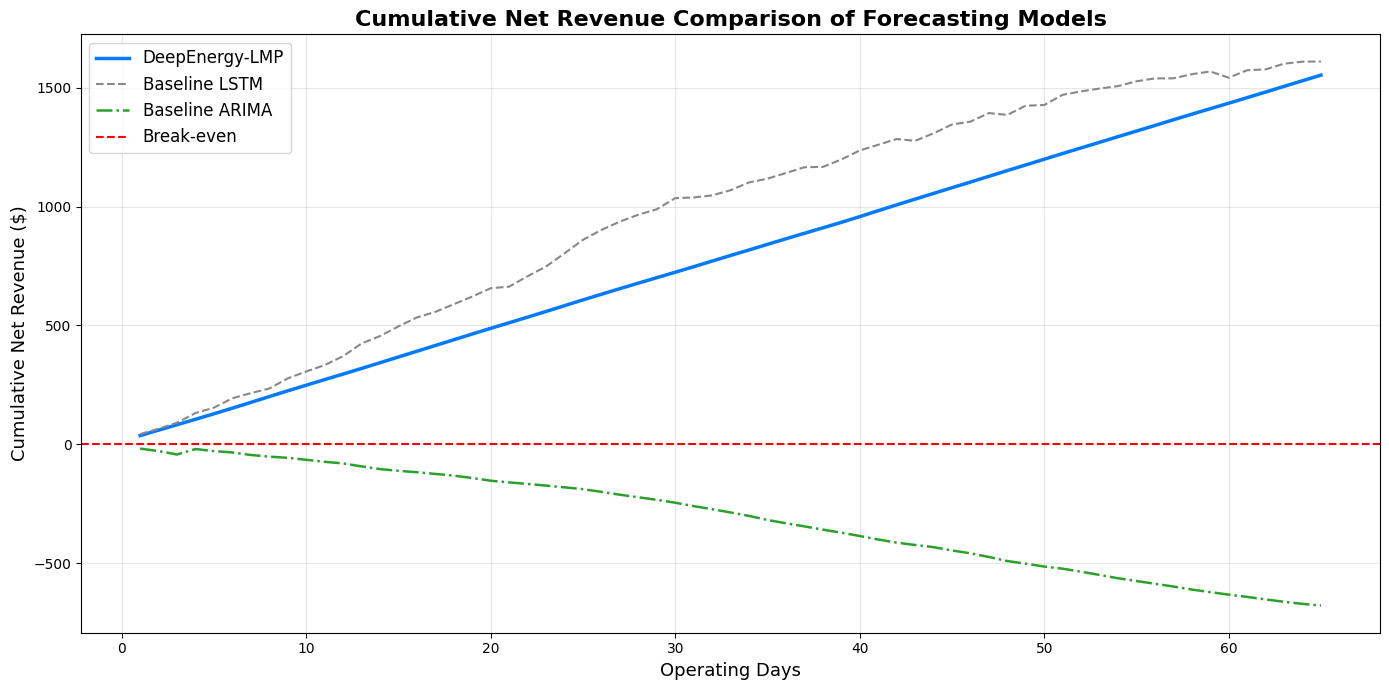

✅ 图已保存: /kaggle/working/model_revenue_comparison.svg


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== 三个模型的每日收益 ====================
tst_daily   = np.array(tst_daily_profits)    # PatchTST
lstm_daily  = np.array(lstm_daily_profits)   # LSTM
arima_daily = np.array(arima_daily_profits)  # ARIMA

# ==================== 计算累计收益 ====================
tst_cum   = np.cumsum(tst_daily)
lstm_cum  = np.cumsum(lstm_daily)
arima_cum = np.cumsum(arima_daily)

days = np.arange(1, len(tst_cum)+1)

# ==================== 绘图 ====================
plt.figure(figsize=(14,7))

# PatchTST（主角：亮蓝 + 加粗）
plt.plot(
    days, tst_cum,
    color='#007BFF',       # 亮蓝色
    linewidth=2.5,
    label='DeepEnergy-LMP'
)

# LSTM（弱化：灰色 + 虚线 + 细）
plt.plot(
    days, lstm_cum,
    color='#888888',       # 灰色
    linewidth=1.5,
    linestyle='--',
    label='Baseline LSTM'
)

# ARIMA（普通：绿色点划线）
plt.plot(
    days, arima_cum,
    color='#2ca02c',
    linewidth=1.8,
    linestyle='-.',
    label='Baseline ARIMA'
)

# 盈亏平衡线
plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Break-even'
)

# ==================== 图形美化 ====================
plt.title(
    "Cumulative Net Revenue Comparison of Forecasting Models",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Operating Days", fontsize=13)
plt.ylabel("Cumulative Net Revenue ($)", fontsize=13)

plt.grid(True, alpha=0.3)

plt.legend(fontsize=12)

plt.tight_layout()

# ==================== 保存SVG ====================
plt.savefig(
    "/kaggle/working/model_revenue_comparison.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("✅ 图已保存: /kaggle/working/model_revenue_comparison.svg")

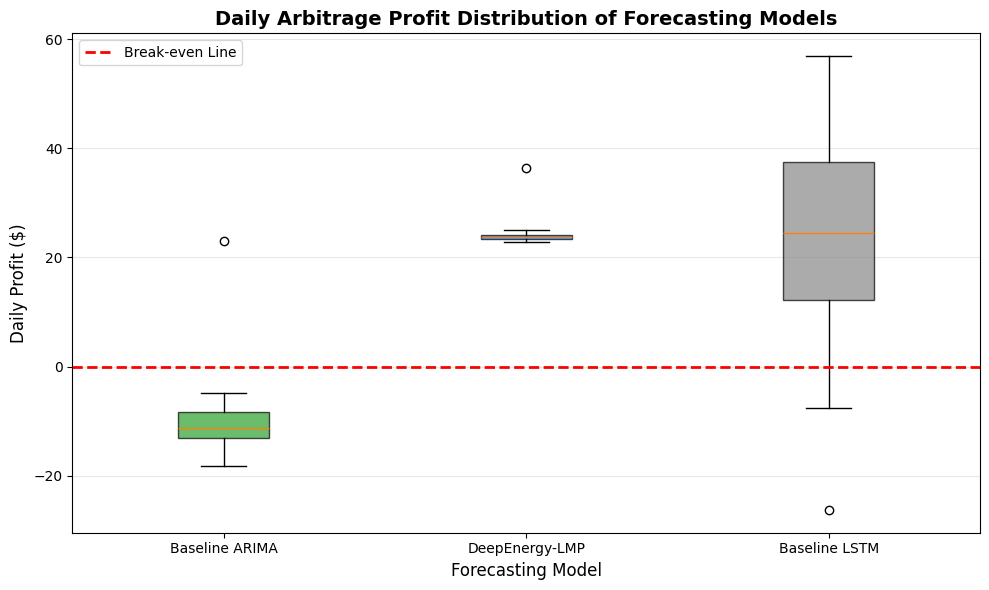

✅ 图已保存: /kaggle/working/daily_profit_boxplot.svg


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ==================== 三个模型每日收益 ====================
df = pd.DataFrame({
    "ARIMA": arima_daily_profits,
    "LSTM": lstm_daily_profits,
    "TST": tst_daily_profits
})

# 转成长格式（方便画图）
df_melt = df.melt(var_name="Model", value_name="Daily Profit")

# ==================== 绘图 ====================
plt.figure(figsize=(10,6))

box = plt.boxplot(
    [df["ARIMA"], df["TST"],df["LSTM"]],
    tick_labels=["Baseline ARIMA","DeepEnergy-LMP","Baseline LSTM"],
    patch_artist=True,
    showfliers=True
)

# 设置颜色
# 设置颜色对应累计收益图
colors = ["#2ca02c", "#007BFF", "#888888"]  # 顺序要对应 boxplot 里的模型顺序

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
# ==================== 盈亏平衡线 ====================
plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Break-even Line'
)

# ==================== 图形设置 ====================
plt.title("Daily Arbitrage Profit Distribution of Forecasting Models",
          fontsize=14, fontweight='bold')

plt.xlabel("Forecasting Model", fontsize=12)
plt.ylabel("Daily Profit ($)", fontsize=12)

plt.grid(axis='y', alpha=0.3)

plt.legend()

plt.tight_layout()

# ==================== 保存 ====================
plt.savefig("/kaggle/working/daily_profit_boxplot.svg",
            format="svg",
            bbox_inches="tight")

plt.show()

print("✅ 图已保存: /kaggle/working/daily_profit_boxplot.svg")

实际使用天数: 65
统一套利阈值:
HIGH: 39.25443
LOW : 12.71914075

开始运行套利模拟...

========== TST收益统计 ==========
天数: 65

模型收益
日均收益: 23.752757334984114
最大日收益: 33.65978627156047
最小日收益: 9.545650407744692
累计收益: 1543.9292267739675

Oracle收益
累计收益: 1825.386156366446

收益效率
Profit Ratio: 0.8458096504069378


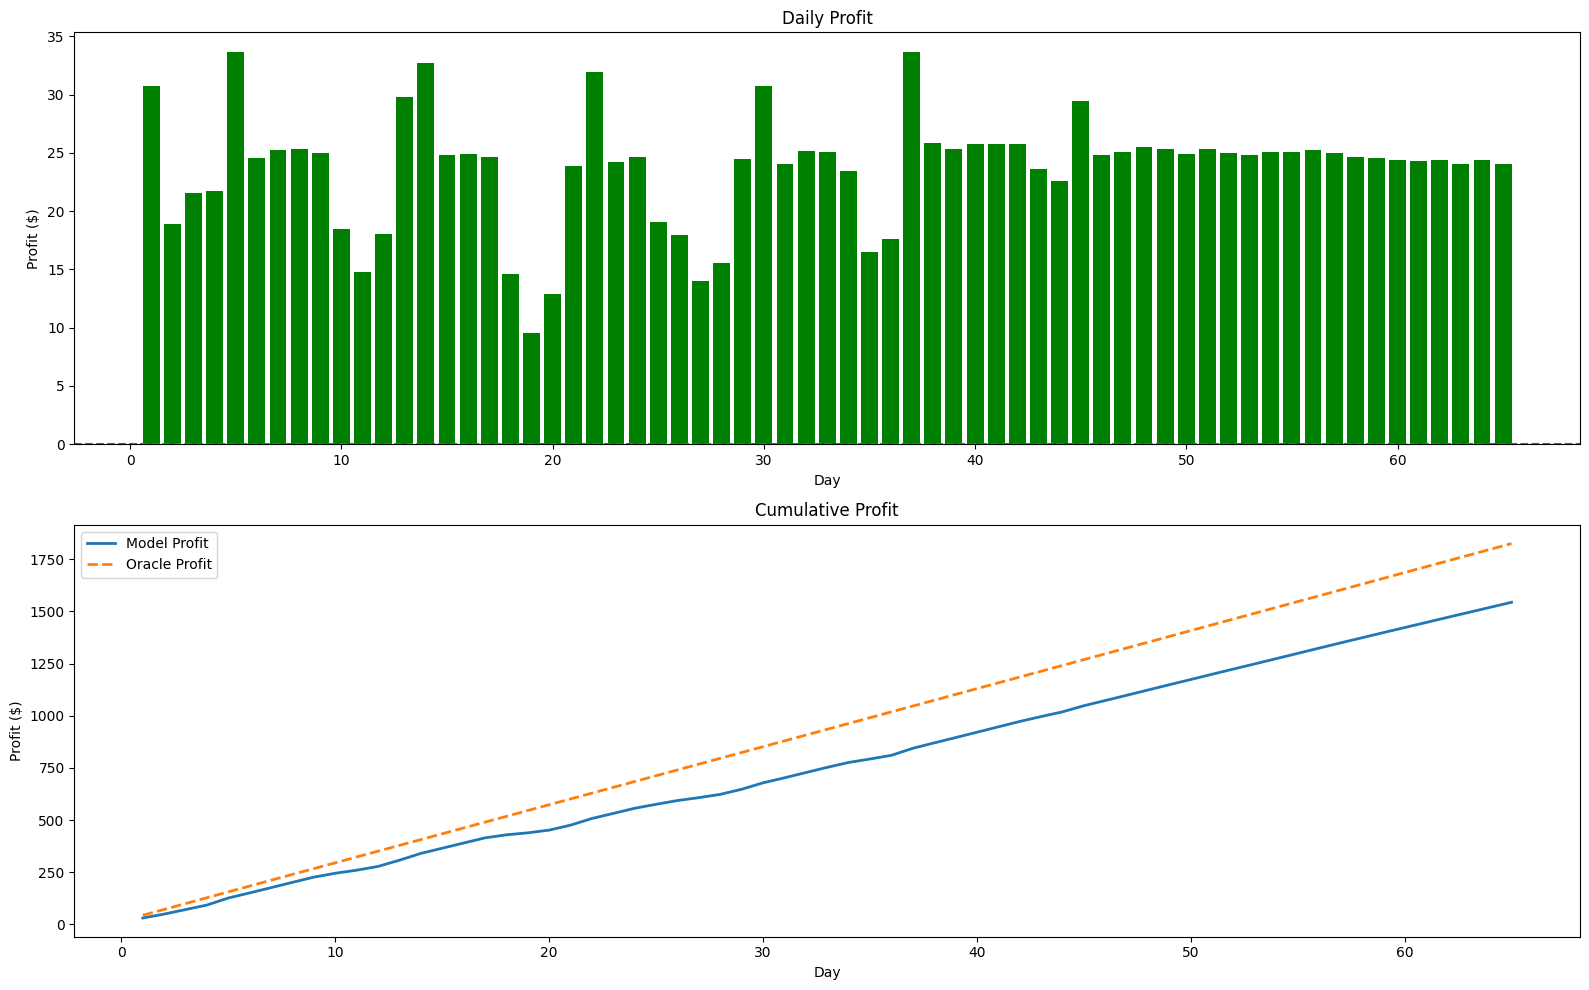


图已保存:
/kaggle/working/arbitrage_profi1.svg


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==================== 电池参数 ====================
E_cap = 1.0
P_max = 0.25
eta_c = 0.95
eta_d = 0.95
SOC_min = 0.1
SOC_max = 0.9
SOC_init = 0.5
dt = 1/12  # 5分钟

# 电池寿命参数
C_inv = 300
Gamma_life = 3000
omega_base = 1.0

# ==================== 读取数据 ====================
df = pd.read_csv('/kaggle/input/datasets/chongwentang/tst-prediction-new/tst_prediction_results (1).csv')

true_vals = df['true_LMP'].values
pred_vals = df['predicted_LMP'].values

# ==================== 按天切分 ====================
points_per_day = 288

pred_days = []
true_days = []

for i in range(0, len(true_vals), points_per_day):

    if i + points_per_day > len(true_vals):
        break

    pred_days.append(pred_vals[i:i+points_per_day])
    true_days.append(true_vals[i:i+points_per_day])

pred_days = pred_days[:-1]
true_days = true_days[:-1]

pred_prices = np.array(pred_days)
true_prices = np.array(true_days)

print("实际使用天数:", len(pred_prices))

# ==================== 统一套利阈值 ====================
all_true_prices = true_prices.flatten()

PRICE_HIGH = np.percentile(all_true_prices, 75)
PRICE_LOW  = np.percentile(all_true_prices, 25)

print("统一套利阈值:")
print("HIGH:", PRICE_HIGH)
print("LOW :", PRICE_LOW)

# ==================== 电池老化成本 ====================
def battery_degradation(P_c, P_d):

    return omega_base * (C_inv / (2 * Gamma_life * E_cap)) * \
           (eta_c * P_c + P_d / eta_d) * dt

# ==================== 贪心套利策略 ====================
def greedy_dispatch(price_forecast, SOC_start):

    T = len(price_forecast)

    P_c = np.zeros(T)
    P_d = np.zeros(T)

    SOC = np.zeros(T+1)
    SOC[0] = SOC_start

    for t in range(T):

        p = price_forecast[t]
        soc = SOC[t]

        # 放电
        if p >= PRICE_HIGH and soc > SOC_min:

            max_discharge = min(
                P_max,
                (soc - SOC_min) * E_cap / dt * eta_d
            )

            P_d[t] = max_discharge

        # 充电
        elif p <= PRICE_LOW and soc < SOC_max:

            max_charge = min(
                P_max,
                (SOC_max - soc) * E_cap / (dt * eta_c)
            )

            P_c[t] = max_charge

        # SOC更新
        SOC[t+1] = soc + (eta_c * P_c[t] - P_d[t] / eta_d) * dt / E_cap
        SOC[t+1] = np.clip(SOC[t+1], SOC_min, SOC_max)

    return P_c, P_d, SOC


# ==================== 利润计算 ====================
def calc_profit(true_price, P_c, P_d):

    profit = 0

    for t in range(len(true_price)):

        revenue = true_price[t] * P_d[t] * dt
        cost    = true_price[t] * P_c[t] * dt
        deg     = battery_degradation(P_c[t], P_d[t])

        profit += revenue - cost - deg

    return profit


# ==================== Oracle最优策略 ====================
def oracle_dispatch(true_price, SOC_start):

    return greedy_dispatch(true_price, SOC_start)


# ==================== 运行套利 ====================
n_days = len(pred_prices)

daily_profit_model = []
daily_profit_oracle = []

SOC_model = SOC_init
SOC_oracle = SOC_init

print("\n开始运行套利模拟...")

for day in range(n_days):

    # 模型策略
    P_c, P_d, SOC = greedy_dispatch(
        pred_prices[day],
        SOC_model
    )

    profit = calc_profit(true_prices[day], P_c, P_d)

    daily_profit_model.append(profit)

    SOC_model = SOC[-1]

    # Oracle策略
    P_c_o, P_d_o, SOC_o = oracle_dispatch(
        true_prices[day],
        SOC_oracle
    )

    profit_o = calc_profit(true_prices[day], P_c_o, P_d_o)

    daily_profit_oracle.append(profit_o)

    SOC_oracle = SOC_o[-1]


daily_profit_model = np.array(daily_profit_model)
daily_profit_oracle = np.array(daily_profit_oracle)

cum_model = np.cumsum(daily_profit_model)
cum_oracle = np.cumsum(daily_profit_oracle)

# ==================== 统计指标 ====================
print("\n========== TST收益统计 ==========")

print("天数:", n_days)

print("\n模型收益")

print("日均收益:", np.mean(daily_profit_model))
print("最大日收益:", np.max(daily_profit_model))
print("最小日收益:", np.min(daily_profit_model))
print("累计收益:", cum_model[-1])

print("\nOracle收益")

print("累计收益:", cum_oracle[-1])

print("\n收益效率")

print("Profit Ratio:",
      cum_model[-1] / cum_oracle[-1])


# ==================== 绘图 ====================
days = np.arange(1, n_days+1)

fig, axes = plt.subplots(2,1, figsize=(16,10))

# 日收益
colors = ['green' if p >= 0 else 'red' for p in daily_profit_model]

axes[0].bar(days, daily_profit_model, color=colors)

axes[0].set_title("Daily Profit")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Profit ($)")

axes[0].axhline(0, linestyle="--")

# 累计收益
axes[1].plot(days, cum_model, label="Model Profit", linewidth=2)

axes[1].plot(days, cum_oracle,
             label="Oracle Profit",
             linestyle="--",
             linewidth=2)

axes[1].set_title("Cumulative Profit")

axes[1].set_xlabel("Day")
axes[1].set_ylabel("Profit ($)")

axes[1].legend()

plt.tight_layout()

plt.savefig("/kaggle/working/arbitrage_profit1.svg")

plt.show()

print("\n图已保存:")
print("/kaggle/working/arbitrage_profi1.svg")

实际使用天数: 65
统一套利阈值:
HIGH: 48.106625
LOW : 27.8432

开始运行套利模拟...

========== LSTM收益统计 ==========
天数: 65

模型收益
日均收益: 14.454356796332263
最大日收益: 71.6308189725762
最小日收益: -13.47308869517546
累计收益: 939.5331917615973

Oracle收益
累计收益: 1016.3293944682725

收益效率
Profit Ratio: 0.9244376841556828


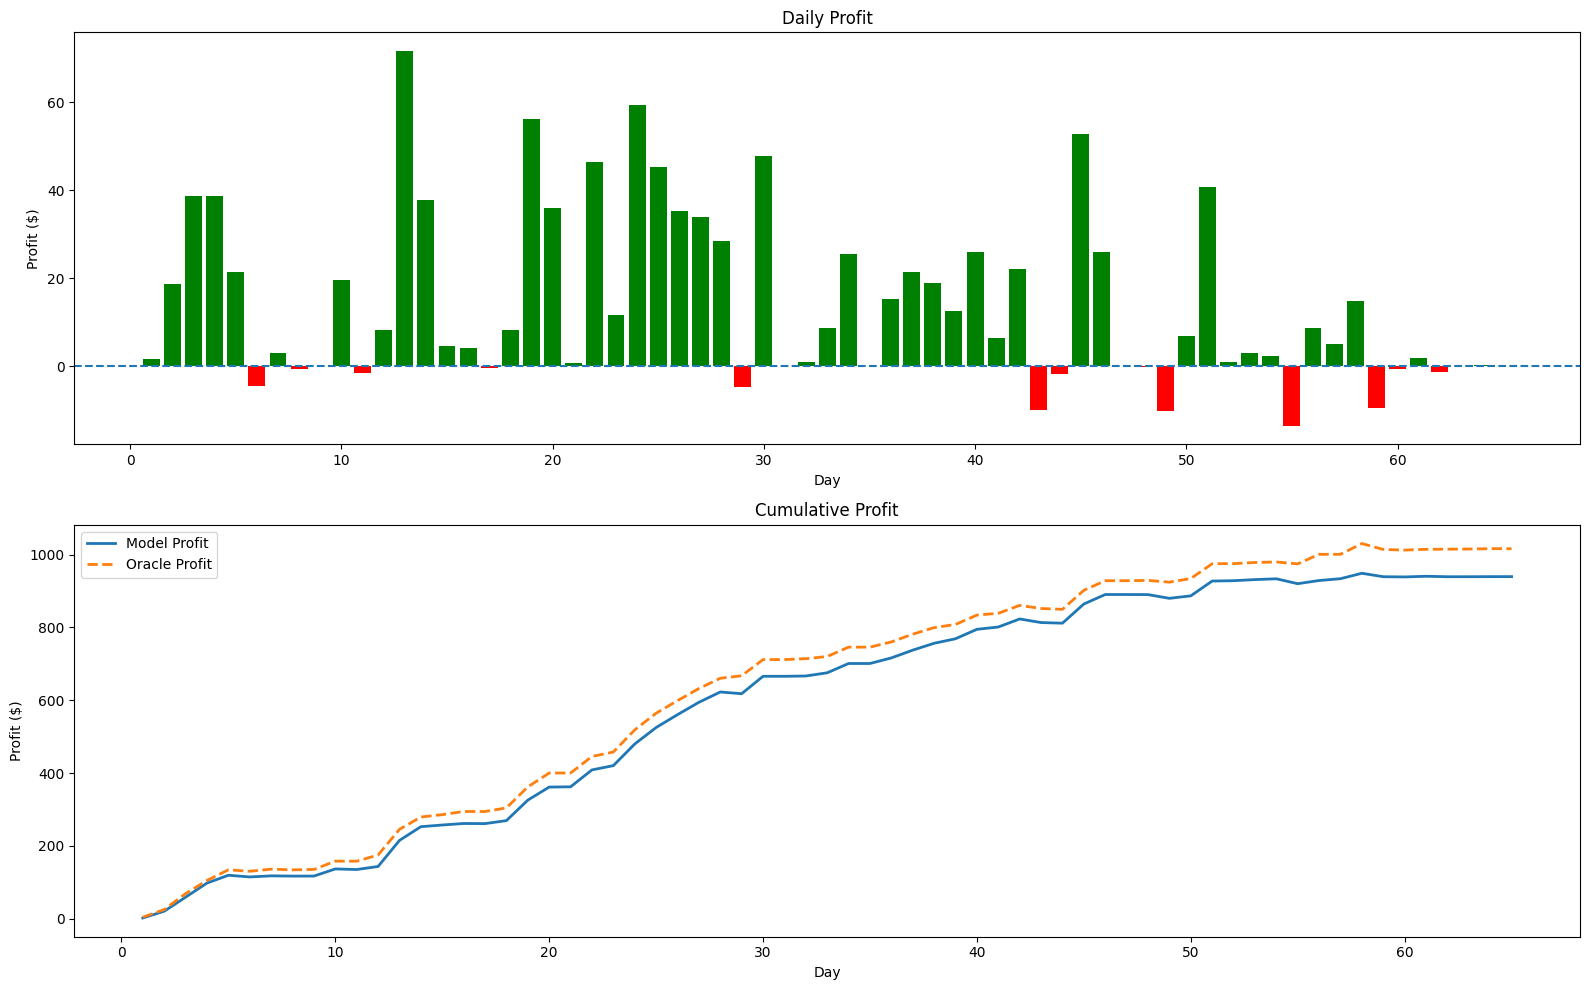


图已保存:
/kaggle/working/arbitrage_profi2.svg


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==================== 电池参数 ====================
E_cap = 1.0
P_max = 0.25
eta_c = 0.95
eta_d = 0.95
SOC_min = 0.1
SOC_max = 0.9
SOC_init = 0.5
dt = 1/12  # 5分钟

# 电池寿命参数
C_inv = 300
Gamma_life = 3000
omega_base = 1.0

# ==================== 读取数据 ====================
df = pd.read_csv('/kaggle/input/datasets/chongwentang/lstm-predictions-new/lstm_predictions(3).csv')

true_vals = df['True_Value'].values
pred_vals = df['LSTM_Predicted'].values

# ==================== 按天切分 ====================
points_per_day = 288

pred_days = []
true_days = []

for i in range(0, len(true_vals), points_per_day):

    if i + points_per_day > len(true_vals):
        break

    pred_days.append(pred_vals[i:i+points_per_day])
    true_days.append(true_vals[i:i+points_per_day])

pred_days = pred_days[:-1]
true_days = true_days[:-1]

pred_prices = np.array(pred_days)
true_prices = np.array(true_days)

print("实际使用天数:", len(pred_prices))

# ==================== 统一套利阈值 ====================
all_true_prices = true_prices.flatten()

PRICE_HIGH = np.percentile(all_true_prices, 75)
PRICE_LOW  = np.percentile(all_true_prices, 25)

print("统一套利阈值:")
print("HIGH:", PRICE_HIGH)
print("LOW :", PRICE_LOW)

# ==================== 电池老化成本 ====================
def battery_degradation(P_c, P_d):

    return omega_base * (C_inv / (2 * Gamma_life * E_cap)) * \
           (eta_c * P_c + P_d / eta_d) * dt

# ==================== 贪心套利策略 ====================
def greedy_dispatch(price_forecast, SOC_start):

    T = len(price_forecast)

    P_c = np.zeros(T)
    P_d = np.zeros(T)

    SOC = np.zeros(T+1)
    SOC[0] = SOC_start

    for t in range(T):

        p = price_forecast[t]
        soc = SOC[t]

        # 放电
        if p >= PRICE_HIGH and soc > SOC_min:

            max_discharge = min(
                P_max,
                (soc - SOC_min) * E_cap / dt * eta_d
            )

            P_d[t] = max_discharge

        # 充电
        elif p <= PRICE_LOW and soc < SOC_max:

            max_charge = min(
                P_max,
                (SOC_max - soc) * E_cap / (dt * eta_c)
            )

            P_c[t] = max_charge

        # SOC更新
        SOC[t+1] = soc + (eta_c * P_c[t] - P_d[t] / eta_d) * dt / E_cap
        SOC[t+1] = np.clip(SOC[t+1], SOC_min, SOC_max)

    return P_c, P_d, SOC


# ==================== 利润计算 ====================
def calc_profit(true_price, P_c, P_d):

    profit = 0

    for t in range(len(true_price)):

        revenue = true_price[t] * P_d[t] * dt
        cost    = true_price[t] * P_c[t] * dt
        deg     = battery_degradation(P_c[t], P_d[t])

        profit += revenue - cost - deg

    return profit


# ==================== Oracle最优策略 ====================
def oracle_dispatch(true_price, SOC_start):

    return greedy_dispatch(true_price, SOC_start)


# ==================== 运行套利 ====================
n_days = len(pred_prices)

daily_profit_model = []
daily_profit_oracle = []

SOC_model = SOC_init
SOC_oracle = SOC_init

print("\n开始运行套利模拟...")

for day in range(n_days):

    # 模型策略
    P_c, P_d, SOC = greedy_dispatch(
        pred_prices[day],
        SOC_model
    )

    profit = calc_profit(true_prices[day], P_c, P_d)

    daily_profit_model.append(profit)

    SOC_model = SOC[-1]

    # Oracle策略
    P_c_o, P_d_o, SOC_o = oracle_dispatch(
        true_prices[day],
        SOC_oracle
    )

    profit_o = calc_profit(true_prices[day], P_c_o, P_d_o)

    daily_profit_oracle.append(profit_o)

    SOC_oracle = SOC_o[-1]


daily_profit_model = np.array(daily_profit_model)
daily_profit_oracle = np.array(daily_profit_oracle)

cum_model = np.cumsum(daily_profit_model)
cum_oracle = np.cumsum(daily_profit_oracle)

# ==================== 统计指标 ====================
print("\n========== LSTM收益统计 ==========")

print("天数:", n_days)

print("\n模型收益")

print("日均收益:", np.mean(daily_profit_model))
print("最大日收益:", np.max(daily_profit_model))
print("最小日收益:", np.min(daily_profit_model))
print("累计收益:", cum_model[-1])

print("\nOracle收益")

print("累计收益:", cum_oracle[-1])

print("\n收益效率")

print("Profit Ratio:",
      cum_model[-1] / cum_oracle[-1])


# ==================== 绘图 ====================
days = np.arange(1, n_days+1)

fig, axes = plt.subplots(2,1, figsize=(16,10))

# 日收益
colors = ['green' if p >= 0 else 'red' for p in daily_profit_model]

axes[0].bar(days, daily_profit_model, color=colors)

axes[0].set_title("Daily Profit")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Profit ($)")

axes[0].axhline(0, linestyle="--")

# 累计收益
axes[1].plot(days, cum_model, label="Model Profit", linewidth=2)

axes[1].plot(days, cum_oracle,
             label="Oracle Profit",
             linestyle="--",
             linewidth=2)

axes[1].set_title("Cumulative Profit")

axes[1].set_xlabel("Day")
axes[1].set_ylabel("Profit ($)")

axes[1].legend()

plt.tight_layout()

plt.savefig("/kaggle/working/arbitrage_profit2.svg")

plt.show()

print("\n图已保存:")
print("/kaggle/working/arbitrage_profi2.svg")